In [1]:
import sys

sys.path.insert(0, 'backend_functions')

import selection_functions as sf

import importlib

import uproot
import matplotlib.pylab as pylab
import numpy as np
import math
from sklearn.model_selection import train_test_split
import xgboost as xgb

import awkward
import matplotlib.pyplot as plt
import pandas as pd

# Top is where parameters(ISRUN3) is defined!
import top 
from top import *

# Reload modules to pick up any changes
importlib.reload(sf)
from selection_functions import *

importlib.reload(top)
from top import *

import pandas as pd
import numpy as np

In [2]:
ISRUN3 = True
NUE_INTRINSIC = True

In [3]:
plots_path = parameters(ISRUN3)['plots_path']
plots_path

'/Users/abarnard/phd/ccnp/uBNuMI_CC1eNp/plots/rhc/'

In [4]:
pandora_fold = "nuselection"
pandora_tree = "NeutrinoSelectionFilter"

# Event-level variables
wc1_fold = "wcpselection"
wc1_tree = "T_eval"

# BDT variables
wc2_fold = "wcpselection"
wc2_tree = "T_BDTvars"

# Particle-level variables
wc3_fold = "wcpselection"
wc3_tree = "T_PFeval"

DATA = ""
EXT = ""
OVRLY  = ""
DRT = ""
NUE = ""

path = parameters(ISRUN3)['run4b_path']
print('path = ', path)

if not ISRUN3: 

    # Run 1 FHC 
    OVRLY = 'numi_nu_run1'
    EXT = 'neutrinoselection_filt_run1_beamoff_v5'
    DATA = 'neutrinoselection_filt_run1_beamon_beamgood_v5'
    DRT = 'prodgenie_numi_uboone_overlay_dirt_fhc_mcc9_run1_v28_all_snapshot'
    
    if NUE_INTRINSIC: 
        NUE = 'numi_nue_run1' 


else: 
 
    # Run 4 RHC
    OVRLY = 'checkout_MCC9.10_Run4b_NuMI_RHC_nu_overlay_surprise_v10_04_07_09_reco2_hist'
    DATA = 'checkout_MCC9.10_Run4b_NuMI_beam_on_RHC_data_surprise_v10_04_07_09_reco2_hist'
    EXT = 'checkout_MCC9.10_Run4b_NuMI_beam_off_RHC_data_surprise_v10_04_07_09_reco2_hist'
    # DRT = 'neutrinoselection_filt_run3b_dirt_overlay_v6'
    
    if NUE_INTRINSIC: 
        NUE = 'checkout_MCC9.10_Run4b_NuMI_RHC_nue_overlay_surprise_v10_04_07_09_reco2_hist'


path =  /pnfs/uboone/persistent/users/uboonepro/surprise/run4b_full_samples/wc_processed/NuMI/


In [5]:
variables = [
    "trk_score_v", 
    "shr_tkfit_dedx_Y", 
    "n_tracks_contained", 
    "NeutrinoEnergy2",
    "run","sub","evt",
    "reco_nu_vtx_sce_x","reco_nu_vtx_sce_y","reco_nu_vtx_sce_z",
    "shrsubclusters0","shrsubclusters1","shrsubclusters2",
    "trkshrhitdist2",
    "n_showers_contained", 
    "shr_phi", "trk_phi", "trk_theta",
    "shr_score", 
    "trk_energy", 
    "tksh_distance", "tksh_angle",
    "shr_energy_tot_cali", "shr_energy_cali", 
    "nslice", 
    "contained_fraction",
    "shrmoliereavg", "shr_px", "shr_py", "shr_pz","swtrig_pre", "slice_orig_pass_id",
    # NuGraph slice hit counts (can use these as normal variables)
    "slcng2mip", "slcng2hip", "slcng2shr", "slcng2mcl", "slcng2dfs",
    # NuGraph clustered hit counts
    "clung2mip", "clung2hip", "clung2shr", "clung2mcl", "clung2dfs",
    # Number of HIP-labeled hits within 1/3/5/10 cm of neutrino vertex
    "ng2hip_r1cm", "ng2hip_r10cm",
    # More dE/dx variables
    "shr_tkfit_gap10_dedx_Y", "shr_tkfit_2cm_dedx_Y",

    # WireCell variables
    "reco_nuvtxX", "reco_nuvtxY", "reco_nuvtxZ", "nue_score", "numu_cc_flag", "match_isFC",
    "reco_Ntrack", "reco_mother", "reco_pdg", "reco_startMomentum", "reco_showerKE"
]

# MC only variables
mc_var = ["nu_pdg", "shr_theta", "true_e_visible", "ccnc", "interaction", 
          "nproton", "nu_e", "npi0", "npion",
          "true_nu_vtx_x", "true_nu_vtx_y" , "true_nu_vtx_z", 
          "weightTune", "weightSpline", "weightSplineTimesTune", 
          "true_nu_px", "true_nu_py", "true_nu_pz", 
          "elec_e", "proton_e", "mc_px", "mc_py", "mc_pz", "elec_px", "elec_py", "elec_pz", 
           "ppfx_cv", "mc_pdg"]#, "opening_angle"]


In [6]:
# ====================== FIXED STREAMING + LOADER ======================
import uproot, awkward as ak, pandas as pd
from pathlib import Path
import pickle
import os

# --------------------------------------------------------------------------
# 1) Make sure variables & mc_var exist
# --------------------------------------------------------------------------
if "variables" not in globals():
    raise RuntimeError("ERROR: 'variables' list is not defined in the notebook.")

if "mc_var" not in globals():
    raise RuntimeError("ERROR: 'mc_var' list is not defined in the notebook.")

print("Using", len(variables), "variables and", len(mc_var), "MC-only variables")

# --------------------------------------------------------------------------
# 2) Cache directory (using pickle instead of parquet)
# --------------------------------------------------------------------------
OUTDIR_BASE = "/tmp/uproot_cache"
Path(OUTDIR_BASE).mkdir(exist_ok=True, parents=True)

# --------------------------------------------------------------------------
# 3) Stream and load data directly into memory
# --------------------------------------------------------------------------
def load_combined_dataframes(rootfile, tag, is_mc=True):
    """Load all trees and combine them into a single DataFrame."""
    
    # Clear cache to ensure fresh data loading
    cache_file = Path(OUTDIR_BASE) / f"{tag}_combined.pkl"
    if cache_file.exists():
        os.remove(cache_file)
    
    print(f"Loading {tag} from: {rootfile}")
    
    # Open file and get trees
    f = uproot.open(rootfile)
    
    pandora_tree_obj = f[f"{pandora_fold}/{pandora_tree}"]
    wc1_tree_obj = f[f"{wc1_fold}/{wc1_tree}"]
    wc2_tree_obj = f[f"{wc2_fold}/{wc2_tree}"]
    wc3_tree_obj = f[f"{wc3_fold}/{wc3_tree}"]
    
    # Get needed branches
    needed_branches = list(variables) + (list(mc_var) if is_mc else [])
    
    # Find which branches exist in each tree
    pandora_branches = set(pandora_tree_obj.keys())
    wc1_branches = set(wc1_tree_obj.keys())
    wc2_branches = set(wc2_tree_obj.keys())
    wc3_branches = set(wc3_tree_obj.keys())
    
    pandora_cols = [b for b in needed_branches if b in pandora_branches]
    wc1_cols = [b for b in needed_branches if b in wc1_branches]
    wc2_cols = [b for b in needed_branches if b in wc2_branches]
    wc3_cols = [b for b in needed_branches if b in wc3_branches]
    
    print(f"Loading {len(pandora_cols)} pandora, {len(wc1_cols)} wc1, {len(wc2_cols)} wc2, {len(wc3_cols)} wc3 branches")
    
    dfs = []
    
    # Load each tree's data
    if pandora_cols:
        print("Loading pandora tree...")
        pandora_df = pandora_tree_obj.arrays(pandora_cols, library="pd").add_prefix("pandora_")
        dfs.append(pandora_df.reset_index(drop=True))
    
    if wc1_cols:
        print("Loading wc1 tree...")
        wc1_df = wc1_tree_obj.arrays(wc1_cols, library="pd").add_prefix("wc1_")
        dfs.append(wc1_df.reset_index(drop=True))
    
    if wc2_cols:
        print("Loading wc2 tree...")
        wc2_df = wc2_tree_obj.arrays(wc2_cols, library="pd").add_prefix("wc2_")
        dfs.append(wc2_df.reset_index(drop=True))
    
    if wc3_cols:
        print("Loading wc3 tree...")
        wc3_df = wc3_tree_obj.arrays(wc3_cols, library="pd").add_prefix("wc3_")
        dfs.append(wc3_df.reset_index(drop=True))
    
    f.close()
    
    # Ensure all DataFrames have the same length
    if dfs:
        minlen = min(len(df) for df in dfs)
        dfs = [df.iloc[:minlen].reset_index(drop=True) for df in dfs]
        
        # Combine all DataFrames
        combined_df = pd.concat(dfs, axis=1)
        print(f"Combined shape: {combined_df.shape}")
        
        # Cache the result
        print(f"Caching to {cache_file}...")
        combined_df.to_pickle(cache_file)
        
        return combined_df
    else:
        return pd.DataFrame()

# --------------------------------------------------------------------------
# 4) Load data for each sample type
# --------------------------------------------------------------------------

def try_load(filename_base, tag, is_mc):
    if filename_base:
        full = path + filename_base + ".root"
        return load_combined_dataframes(full, tag, is_mc=is_mc)
    else:
        print(f"Skipping {tag}: filename empty")
        return pd.DataFrame()

# Load all datasets
print("=" * 50)
print("LOADING DATASETS")
print("=" * 50)

overlay_df = try_load(OVRLY, "overlay", is_mc=True)
data_df = try_load(DATA, "data", is_mc=False)
ext_df = try_load(EXT, "ext", is_mc=True)

if NUE_INTRINSIC:
    nue_df = try_load(NUE, "nue", is_mc=True)
else:
    nue_df = pd.DataFrame()

# --------------------------------------------------------------------------
# 5) Helper functions to get individual tree data
# --------------------------------------------------------------------------

def get_tree_df(df, tree="pandora"):
    """Extract single tree DataFrame from combined DataFrame."""
    if df.empty:
        return df
        
    pref = tree + "_"
    cols = [c for c in df.columns if c.startswith(pref)]
    
    if not cols:
        return pd.DataFrame()
    
    tree_df = df[cols].copy()
    tree_df.columns = [c.replace(pref, "") for c in cols]
    
    # Keep only variables that exist
    tree_df = tree_df[[v for v in variables if v in tree_df.columns]]
    return tree_df

def get_combined_df(tag):
    """Get combined DataFrame by tag name."""
    if tag == "overlay":
        return overlay_df
    elif tag == "data":
        return data_df
    elif tag == "ext":
        return ext_df
    elif tag == "nue":
        return nue_df
    else:
        print(f"Unknown tag: {tag}")
        return pd.DataFrame()

print("\n" + "=" * 50)
print("SETUP COMPLETE")
print("=" * 50)
print("Available functions:")
print("- get_combined_df('overlay') - get full combined DataFrame")
print("- get_tree_df(get_combined_df('overlay'), 'pandora') - get single tree data")
print("- overlay_df, data_df, ext_df, nue_df - direct access to DataFrames")

if not overlay_df.empty:
    print(f"\nOverlay shape: {overlay_df.shape}")
if not data_df.empty:
    print(f"Data shape: {data_df.shape}")
if not ext_df.empty:
    print(f"EXT shape: {ext_df.shape}")
if not nue_df.empty:
    print(f"NUE shape: {nue_df.shape}")

Using 57 variables and 28 MC-only variables
LOADING DATASETS
Loading overlay from: /pnfs/uboone/persistent/users/uboonepro/surprise/run4b_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4b_NuMI_RHC_nu_overlay_surprise_v10_04_07_09_reco2_hist.root
Loading 74 pandora, 2 wc1, 4 wc2, 9 wc3 branches
Loading pandora tree...
Loading wc1 tree...
Loading wc2 tree...
Loading wc3 tree...
Combined shape: (612983, 89)
Caching to /tmp/uproot_cache/overlay_combined.pkl...
Loading data from: /pnfs/uboone/persistent/users/uboonepro/surprise/run4b_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4b_NuMI_beam_on_RHC_data_surprise_v10_04_07_09_reco2_hist.root
Loading 46 pandora, 2 wc1, 4 wc2, 9 wc3 branches
Loading pandora tree...
Loading wc1 tree...
Loading wc2 tree...
Loading wc3 tree...
Combined shape: (759778, 61)
Caching to /tmp/uproot_cache/data_combined.pkl...
Loading ext from: /pnfs/uboone/persistent/users/uboonepro/surprise/run4b_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4b_NuMI_bea

In [7]:
overlay = overlay_df
data = data_df
ext = ext_df
nue = nue_df

In [8]:
# --------------------------------------------------------------------------
# 6) Function to display variable breakdown
# --------------------------------------------------------------------------

def show_variable_breakdown(sample_tag="overlay", show_missing=True):
    """Display which variables are loaded from which trees for a given sample."""
    
    # Get the root file path
    if sample_tag == "overlay":
        rootfile = path + OVRLY + ".root"
        is_mc = True
    elif sample_tag == "data":
        rootfile = path + DATA + ".root"
        is_mc = False
    elif sample_tag == "ext":
        rootfile = path + EXT + ".root"
        is_mc = True
    elif sample_tag == "nue":
        rootfile = path + NUE + ".root"
        is_mc = True
    else:
        print(f"Unknown sample tag: {sample_tag}")
        return
    
    print(f"=" * 60)
    print(f"VARIABLE BREAKDOWN FOR {sample_tag.upper()} SAMPLE")
    print(f"File: {rootfile}")
    print(f"=" * 60)
    
    # Open file and get trees
    f = uproot.open(rootfile)
    
    pandora_tree_obj = f[f"{pandora_fold}/{pandora_tree}"]
    wc1_tree_obj = f[f"{wc1_fold}/{wc1_tree}"]
    wc2_tree_obj = f[f"{wc2_fold}/{wc2_tree}"]
    wc3_tree_obj = f[f"{wc3_fold}/{wc3_tree}"]
    
    # Get needed branches
    needed_branches = list(variables) + (list(mc_var) if is_mc else [])
    
    # Find which branches exist in each tree
    pandora_branches = set(pandora_tree_obj.keys())
    wc1_branches = set(wc1_tree_obj.keys())
    wc2_branches = set(wc2_tree_obj.keys())
    wc3_branches = set(wc3_tree_obj.keys())
    
    pandora_cols = [b for b in needed_branches if b in pandora_branches]
    wc1_cols = [b for b in needed_branches if b in wc1_branches]
    wc2_cols = [b for b in needed_branches if b in wc2_branches]
    wc3_cols = [b for b in needed_branches if b in wc3_branches]
    
    print(f"Total variables requested: {len(needed_branches)}")
    print(f"Found: {len(pandora_cols)} pandora, {len(wc1_cols)} wc1, {len(wc2_cols)} wc2, {len(wc3_cols)} wc3")
    
    # Print detailed information about which variables come from which tree
    print("\n--- DETAILED VARIABLE BREAKDOWN ---")
    if pandora_cols:
        print(f"\nPANDORA TREE ({pandora_fold}/{pandora_tree}) - {len(pandora_cols)} variables:")
        for col in sorted(pandora_cols):
            print(f"  • {col}")
    
    if wc1_cols:
        print(f"\nWC1 TREE ({wc1_fold}/{wc1_tree}) - {len(wc1_cols)} variables:")
        for col in sorted(wc1_cols):
            print(f"  • {col}")
    
    if wc2_cols:
        print(f"\nWC2 TREE ({wc2_fold}/{wc2_tree}) - {len(wc2_cols)} variables:")
        for col in sorted(wc2_cols):
            print(f"  • {col}")
    
    if wc3_cols:
        print(f"\nWC3 TREE ({wc3_fold}/{wc3_tree}) - {len(wc3_cols)} variables:")
        for col in sorted(wc3_cols):
            print(f"  • {col}")
    
    # Check for missing variables
    if show_missing:
        all_loaded = set(pandora_cols + wc1_cols + wc2_cols + wc3_cols)
        missing = set(needed_branches) - all_loaded
        if missing:
            print(f"\n⚠️  MISSING VARIABLES ({len(missing)}):")
            for var in sorted(missing):
                print(f"  • {var}")
        else:
            print(f"\n✓ All {len(needed_branches)} requested variables found!")
    
    print("--- END VARIABLE BREAKDOWN ---")
    
    f.close()

print("\n✓ Added show_variable_breakdown() function")
print("Usage: show_variable_breakdown('overlay')  # or 'data', 'ext', 'nue'")


✓ Added show_variable_breakdown() function
Usage: show_variable_breakdown('overlay')  # or 'data', 'ext', 'nue'


In [9]:
# Show variable breakdown for overlay sample
show_variable_breakdown('overlay')

VARIABLE BREAKDOWN FOR OVERLAY SAMPLE
File: /pnfs/uboone/persistent/users/uboonepro/surprise/run4b_full_samples/wc_processed/NuMI/checkout_MCC9.10_Run4b_NuMI_RHC_nu_overlay_surprise_v10_04_07_09_reco2_hist.root
Total variables requested: 85
Found: 74 pandora, 2 wc1, 4 wc2, 9 wc3

--- DETAILED VARIABLE BREAKDOWN ---

PANDORA TREE (nuselection/NeutrinoSelectionFilter) - 74 variables:
  • NeutrinoEnergy2
  • ccnc
  • clung2dfs
  • clung2hip
  • clung2mcl
  • clung2mip
  • clung2shr
  • contained_fraction
  • elec_e
  • elec_px
  • elec_py
  • elec_pz
  • evt
  • interaction
  • mc_pdg
  • mc_px
  • mc_py
  • mc_pz
  • n_showers_contained
  • n_tracks_contained
  • ng2hip_r10cm
  • ng2hip_r1cm
  • npi0
  • npion
  • nproton
  • nslice
  • nu_e
  • nu_pdg
  • ppfx_cv
  • proton_e
  • reco_nu_vtx_sce_x
  • reco_nu_vtx_sce_y
  • reco_nu_vtx_sce_z
  • run
  • shr_energy_cali
  • shr_energy_tot_cali
  • shr_phi
  • shr_px
  • shr_py
  • shr_pz
  • shr_score
  • shr_theta
  • shr_tkfit_2cm_dedx_

In [10]:
# draw_root_like(nue['ppfx_cv'], bins='auto', xlabel='ppfx_cv', title='ppfx_cv (nue)', logy=False)

In [11]:
# equalize the columns

for var in mc_var: 
    data[var] = np.nan
    ext[var] = np.nan

In [12]:
# is dirt bool

overlay['isDirt'] = False
# dirt['isDirt'] = True

if NUE_INTRINSIC: 
    nue['isDirt'] = False
    
data['isDirt'] = np.nan
ext['isDirt'] = np.nan

In [13]:
# SWITCH TO COMBINED DATAFRAMES THAT INCLUDE ALL VARIABLES (WIRECELL + PANDORA)
print("=" * 60)
print("SWITCHING TO COMBINED DATAFRAMES WITH ALL VARIABLES")
print("=" * 60)

# Store current pandora-only DataFrames as backup
overlay_pandora_only = overlay.copy()
data_pandora_only = data.copy()
ext_pandora_only = ext.copy()
if NUE_INTRINSIC:
    nue_pandora_only = nue.copy()

# Replace with combined DataFrames that include WireCell variables
overlay = overlay_df.copy()
data = data_df.copy()
ext = ext_df.copy()
if NUE_INTRINSIC:
    nue = nue_df.copy()

print("✓ Successfully switched to combined DataFrames!")
print(f"  overlay: {overlay.shape} (was {overlay_pandora_only.shape})")
print(f"  data: {data.shape} (was {data_pandora_only.shape})")
print(f"  ext: {ext.shape} (was {ext_pandora_only.shape})")
if NUE_INTRINSIC:
    print(f"  nue: {nue.shape} (was {nue_pandora_only.shape})")

# Check WireCell variables are present
wc_cols = [col for col in overlay.columns if col.startswith(('wc1_', 'wc2_', 'wc3_'))]
pandora_cols = [col for col in overlay.columns if col.startswith('pandora_')]
print(f"\n✓ WireCell columns available: {len(wc_cols)}")
print(f"✓ Pandora columns available: {len(pandora_cols)}")
print(f"Sample WireCell columns: {wc_cols[:3]}...")

# Create uproot_v for direct tree access (needed for LLR-PID calculations)
print("\nCreating uproot tree objects for LLR-PID calculations...")

# Open the ROOT files and get the pandora trees directly
overlay_pandora_tree = uproot.open(path + OVRLY + ".root")[pandora_fold][pandora_tree]
data_pandora_tree = uproot.open(path + DATA + ".root")[pandora_fold][pandora_tree] 
ext_pandora_tree = uproot.open(path + EXT + ".root")[pandora_fold][pandora_tree]

uproot_v = [overlay_pandora_tree, data_pandora_tree, ext_pandora_tree]

if NUE_INTRINSIC:
    nue_pandora_tree = uproot.open(path + NUE + ".root")[pandora_fold][pandora_tree]
    uproot_v.append(nue_pandora_tree)

print(f"✓ Created uproot_v with {len(uproot_v)} tree objects")
print("  uproot_v[0] = overlay pandora tree")
print("  uproot_v[1] = data pandora tree") 
print("  uproot_v[2] = ext pandora tree")
if NUE_INTRINSIC:
    print("  uproot_v[3] = nue pandora tree")

SWITCHING TO COMBINED DATAFRAMES WITH ALL VARIABLES
✓ Successfully switched to combined DataFrames!
  overlay: (612983, 90) (was (612983, 90))
  data: (759778, 90) (was (759778, 90))
  ext: (1941196, 114) (was (1941196, 114))
  nue: (187037, 90) (was (187037, 90))

✓ WireCell columns available: 15
✓ Pandora columns available: 74
Sample WireCell columns: ['wc1_run', 'wc1_match_isFC', 'wc2_run']...

Creating uproot tree objects for LLR-PID calculations...
✓ Created uproot_v with 4 tree objects
  uproot_v[0] = overlay pandora tree
  uproot_v[1] = data pandora tree
  uproot_v[2] = ext pandora tree
  uproot_v[3] = nue pandora tree


In [14]:
# how to get the LLR-PID value for the "track candidate" (proton for nue selection, muon for numu)
# code from Giuseppe!
#LLR-PID : log-likelihood ratio particle ID 

# df_v = [overlay,data,ext,dirt]
df_v = [overlay,data,ext]

if NUE_INTRINSIC: 
    df_v.append(nue)
    
# Build (df, uproot_tree) pairs only for samples that have the LLR branches
pairs = [(overlay, uproot_v[0]), (ext, uproot_v[2])]
if NUE_INTRINSIC:
    pairs.append((nue, uproot_v[3]))

def compute_n_pfng2_tracks(up):
    """Count the number of particles with pfng2semlabel == 1 (tracks) in each event"""
    arrs = up.arrays(['pfng2semlabel'], library='np')
    pid_v = arrs['pfng2semlabel']
    out = []
    for pid in pid_v:
        # Count how many particles have semantic label == 1 (track)
        n_tracks = np.sum(np.array(pid) == 1)
        out.append(int(n_tracks))
    return out

def compute_n_pfng2_showers(up):
    """Count the number of particles with pfng2semlabel == 2 (showers) in each event"""
    arrs = up.arrays(['pfng2semlabel'], library='np')
    pid_v = arrs['pfng2semlabel']
    out = []
    for pid in pid_v:
        # Count how many particles have semantic label == 2 (shower)
        n_showers = np.sum(np.array(pid) == 2)
        out.append(int(n_showers))
    return out

def compute_trkpid(up):
    arrs = up.arrays(['trk_llr_pid_score_v', 'trk_id'], library='np')
    pid_v = arrs['trk_llr_pid_score_v']
    tid = arrs['trk_id'].astype('int64') - 1  # convert to 0-based, handle uint32 safely
    out = []
    for pid, t in zip(pid_v, tid):
        ti = int(t)
        if 0 <= ti < len(pid):
            out.append(float(pid[ti]))
        else:
            out.append(9999.0)
    return out

# This is the NuGraph Track PID stuff! In G's slides, it says you can use it in the same way
# as the regular Track PID stuff.

def compute_pfng2hipavrg(up): # Equivalent of trkpid score I think
    arrs = up.arrays(['pfng2hipavrg', 'trk_id'], library='np')
    sem_v = arrs['pfng2hipavrg']
    tid = arrs['trk_id'].astype('int64') - 1  # convert to 0-based, handle uint32 safely
    out = []
    for sem, t in zip(sem_v, tid):
        ti = int(t)
        if 0 <= ti < len(sem):
            out.append(float(sem[ti]))
        else:
            out.append(9999.0)
    return out

def compute_pfng2shravrg(up): # Equivalent of shower score I think 
    arrs = up.arrays(['pfng2shravrg', 'shr_id'], library='np')
    sem_v = arrs['pfng2shravrg']
    tid = arrs['shr_id'].astype('int64') - 1  # convert to 0-based, handle uint32 safely
    out = []
    for sem, t in zip(sem_v, tid):
        ti = int(t)
        if 0 <= ti < len(sem):
            out.append(float(sem[ti]))
        else:
            out.append(9999.0)
    return out

def compute_pfng2hipfrac(up):
    arrs = up.arrays(['pfng2hipfrac', 'trk_id'], library='np')
    sem_v = arrs['pfng2hipfrac']
    tid = arrs['trk_id'].astype('int64') - 1  # convert to 0-based, handle uint32 safely
    out = []
    for sem, t in zip(sem_v, tid):
        ti = int(t)
        if 0 <= ti < len(sem):
            out.append(float(sem[ti]))
        else:
            out.append(9999.0)
    return out

def compute_pfng2shrfrac(up):
    arrs = up.arrays(['pfng2shrfrac', 'shr_id'], library='np')
    sem_v = arrs['pfng2shrfrac']
    tid = arrs['shr_id'].astype('int64') - 1  # convert to 0-based, handle uint32 safely
    out = []
    for sem, t in zip(sem_v, tid):
        ti = int(t)
        if 0 <= ti < len(sem):
            out.append(float(sem[ti]))
        else:
            out.append(9999.0)
    return out

# Compute for MC-like samples (overlay, ext, and optionally nue)
for df, up in pairs:
    df['pandora_trkpid'] = compute_trkpid(up)

for df, up in pairs:
    df['pandora_n_pfng2_tracks'] = compute_n_pfng2_tracks(up)

for df, up in pairs:
    df['pandora_n_pfng2_showers'] = compute_n_pfng2_showers(up)

for df, up in pairs:
    df['pandora_pfng2hipavrg'] = compute_pfng2hipavrg(up)

for df, up in pairs:
    df['pandora_pfng2shravrg'] = compute_pfng2shravrg(up)

for df, up in pairs:
    df['pandora_pfng2hipfrac'] = compute_pfng2hipfrac(up)

for df, up in pairs:
    df['pandora_pfng2shrfrac'] = compute_pfng2shrfrac(up)

# Data has no matching uproot entry with LLR branches; fill with NaN to keep columns aligned
data['pandora_trkpid'] = np.nan
data['pandora_n_pfng2_tracks'] = np.nan
data['pandora_n_pfng2_showers'] = np.nan
data['pandora_pfng2hipavrg'] = np.nan
data['pandora_pfng2shravrg'] = np.nan
data['pandora_pfng2hipfrac'] = np.nan
data['pandora_pfng2shrfrac'] = np.nan
# Common derived columns for all samples
for df in [overlay, data, ext] + ([nue] if NUE_INTRINSIC else []):
    df['pandora_subcluster'] = df['pandora_shrsubclusters0'] + df['pandora_shrsubclusters1'] + df['pandora_shrsubclusters2']
    df['pandora_NeutrinoEnergy2_GeV'] = df['pandora_NeutrinoEnergy2'] / 1000.0
    df['pandora_shr_energy_cali'] = df['pandora_shr_energy_cali'] / 0.83

for df in [data, ext]:
    df['wc3_reco_showerKE'] = df['wc3_reco_showerKE'] * 0.95


In [15]:
# mc_df = [overlay, dirt]
mc_df = [overlay]

if NUE_INTRINSIC: 
    mc_df.append(nue)

In [16]:
# Calculate nue and nuebar percentages for intrinsic nue ONLY (before applying df['is_signal'])
# Requires intrinsic nue to be present (NUE_INTRINSIC == True)

print(ISRUN3)

if 'nue' in locals() and isinstance(nue, pd.DataFrame):
    n_nue = int((nue['pandora_nu_pdg'] == 12).sum())
    n_nuebar = int((nue['pandora_nu_pdg'] == -12).sum())
    denom = n_nue + n_nuebar
    nue_pct = (n_nue / denom) * 100 if denom > 0 else float('nan')
    nuebar_pct = (n_nuebar / denom) * 100 if denom > 0 else float('nan')
    print(f"nue sample: nue={n_nue}, nuebar={n_nuebar}, nue%={nue_pct:.2f}, nuebar%={nuebar_pct:.2f}")
else:
    print("Intrinsic nue sample not available (NUE_INTRINSIC=False or 'nue' not loaded).")

True
nue sample: nue=152743, nuebar=34294, nue%=81.66, nuebar%=18.34


In [17]:
# overlay_pot = 2.1844E21
# intrinsic_pot = 3.93021E22
# # intrinsic_pot = 5.12336E22
# data_pot = 2.883E20

# import pandas as pd

# overlay_events = len(overlay)
# intrinsic_events = len(nue) if NUE_INTRINSIC and 'nue' in locals() else 0
# data_events = len(data)

# overlay_events_per_pot = overlay_events / overlay_pot if overlay_pot > 0 else 0
# intrinsic_events_per_pot = intrinsic_events / intrinsic_pot if intrinsic_pot > 0 and intrinsic_events > 0 else 0
# data_events_per_pot = data_events / data_pot if data_pot > 0 else 0

# data_to_overlay_ratio = data_events_per_pot / overlay_events_per_pot if overlay_events_per_pot > 0 else 0

# summary_data = {
#     'Sample': ['Overlay', 'Intrinsic', 'Data'],
#     'POT': [f'{overlay_pot:.4e}', f'{intrinsic_pot:.4e}', f'{data_pot:.4e}'],
#     'Number of Events': [f'{overlay_events:,}', f'{intrinsic_events:,}', f'{data_events:,}'],
#     'Events per POT': [f'{overlay_events_per_pot:.4e}', f'{intrinsic_events_per_pot:.4e}', f'{data_events_per_pot:.4e}'],
#     'Data/Overlay Ratio': ['-', '-', f'{data_to_overlay_ratio:.2f}']
# }

# summary_table = pd.DataFrame(summary_data)
# print("Run 4b Samples:")
# print("=" * 80)
# print(summary_table.to_string(index=False))
# print("=" * 80)

In [18]:
for i,df in enumerate(mc_df):
    
    # is signal bool 
    df['is_signal'] = np.where((df.pandora_nu_pdg==12) & (df.pandora_ccnc==0) & (df.pandora_nproton>0) & (df.pandora_npion==0) & (df.pandora_npi0==0)
                             & (10 <= df.pandora_true_nu_vtx_x) & (df.pandora_true_nu_vtx_x <= 246)
                             & (-106 <= df.pandora_true_nu_vtx_y) & (df.pandora_true_nu_vtx_y <= 106)
                             & (10 <= df.pandora_true_nu_vtx_z) & (df.pandora_true_nu_vtx_z <= 1026)
                             & (df.pandora_elec_e>0.07), True, False)
    
    # Add truth level theta & phi angles (detector & beam coordinates)
    df = addAngles(df)

In [19]:
# corrected visible energy variable - account for electrons below 30 MeV 
# use this variable for the visible energy unfolding 

visible_energy_nothres(overlay)
# visible_energy_nothres(dirt)

In [20]:
# make dataframes equal # of columns 

data['is_signal'] = np.nan
ext['is_signal'] = False

nan_var = ['pandora_thdet', 'pandora_phidet', 'pandora_true_nu_px_beam', 'pandora_true_nu_py_beam', 'pandora_true_nu_pz_beam', 
           'pandora_thbeam', 'pandora_phibeam', 'pandora_true_e_visible2']

for var in mc_var+nan_var: 
    data[var] = np.nan
    ext[var] = np.nan

In [21]:
# some checks 
print(len(nue.query('is_signal==True'))==len(nue.query(signal)))
print(len(nue.query('is_signal==False'))==len(nue.query(not_signal)))

True
True


## Weights

In [22]:
# clean bad weights & values 

for i,df in enumerate(mc_df):

    df.loc[ df['pandora_ppfx_cv'] <= 0, 'pandora_ppfx_cv' ] = 1.
    df.loc[ df['pandora_ppfx_cv'] == np.inf, 'pandora_ppfx_cv' ] = 1.
    df.loc[ df['pandora_ppfx_cv'] > 30, 'pandora_ppfx_cv' ] = 1.
    df.loc[ np.isnan(df['pandora_ppfx_cv']) == True, 'pandora_ppfx_cv' ] = 1.
     
    df.loc[ df['pandora_weightSplineTimesTune'] <= 0, 'pandora_weightSplineTimesTune' ] = 1.
    df.loc[ df['pandora_weightSplineTimesTune'] == np.inf, 'pandora_weightSplineTimesTune' ] = 1.
    df.loc[ df['pandora_weightSplineTimesTune'] > 30, 'pandora_weightSplineTimesTune' ] = 1.
    df.loc[ np.isnan(df['pandora_weightSplineTimesTune']) == True, 'pandora_weightSplineTimesTune' ] = 1.
    
    df.loc[ df['pandora_weightTune'] <= 0, 'pandora_weightTune' ] = 1.
    df.loc[ df['pandora_weightTune'] == np.inf, 'pandora_weightTune' ] = 1.
    df.loc[ df['pandora_weightTune'] > 30, 'pandora_weightTune' ] = 1.
    df.loc[ np.isnan(df['pandora_weightTune']) == True, 'pandora_weightTune' ] = 1.  

        

In [23]:
# POT normalization

beamon_pot = parameters(ISRUN3)['beamon_pot'] 

overlay = pot_scale(overlay, 'overlay', ISRUN3)
# dirt = pot_scale(dirt, 'dirt', ISRUN3)
ext = pot_scale(ext, 'ext', ISRUN3)

if NUE_INTRINSIC: 
    nue = pot_scale(nue, 'intrinsic', ISRUN3)

data['pot_scale'] = [1 for x in range(len(data))]



Adding pot_scale column using dirt & EXT tune....
Adding pot_scale column using dirt & EXT tune....
Adding pot_scale column using dirt & EXT tune....


In [24]:
# combined genie * POT weight * flux weight , ext gets POT weight only 
################################################################
# totweight_data scales to BEAMON

# tuned
overlay['totweight_data'] = overlay['pot_scale']*overlay['pandora_ppfx_cv']*overlay['pandora_weightSplineTimesTune']
# dirt['totweight_data'] = dirt['pot_scale']*dirt['ppfx_cv']*dirt['weightSplineTimesTune']

if NUE_INTRINSIC: 
    nue['totweight_data'] = nue['pot_scale']*nue['pandora_ppfx_cv']*nue['pandora_weightSplineTimesTune']

ext['totweight_data'] = np.nan
data['totweight_data'] = np.nan


In [25]:
ISRUN3

True

## Categories

In [26]:
# replace nue CC events with intrinsic sample

if NUE_INTRINSIC: 
    
    print("# of nueCC in AV in overlay sample = "+str(len(overlay.query(nueCC_query))))
    len1 = len(overlay)
    
    idx = overlay.query(nueCC_query).index
    overlay.drop(idx, inplace=True)
    len2 = len(overlay) 
    print("# of nueCC in AV dropped in overlay = "+str(len1-len2))
    
    overlay = pd.concat([overlay,nue], ignore_index=True)

# of nueCC in AV in overlay sample = 8578
# of nueCC in AV dropped in overlay = 8578


In [27]:
# combine overlay + dirt as MC 

# mc = pd.concat([overlay,dirt], ignore_index=True, sort=True)
mc = pd.concat([overlay], ignore_index=True, sort=True)

infv = mc.query(in_fv_query)
outfv = mc.query(out_fv_query)

In [28]:
# check that everything is accounted for 
print(len(mc)==len(infv)+len(outfv))

if not (len(mc)==len(infv)+len(outfv)): 
    
    d = len(mc) - (len(infv)+len(outfv))
    print(d)
    
    m = pd.concat([infv, outfv])
    diff = np.setdiff1d(list(mc.index),list(m.index))


True


In [29]:
tot_signal_weighted = np.nansum(mc.query('is_signal==True')['totweight_data'])
print('total signal events = '+ str(tot_signal_weighted))


total signal events = 743.4975906625177


In [30]:
# 4 main categories: 

# infv - overlay/dirt events with truth vtx in FV 
# outfv - overlay/dirt events with truth vtx in FV that are classified as neutrinos
# ext - beam OFF data
# data - beam ON data 

In [31]:
# Dataset dictionary declaration
datasets = {
        "infv": infv, 
        "outfv": outfv,
        "ext": ext
        # "data": data 
    }

In [32]:
# Intrinsic nue weights for software trigger plot
nue['totweight_intrinsic'] = nue['pandora_ppfx_cv']*nue['pandora_weightSplineTimesTune']

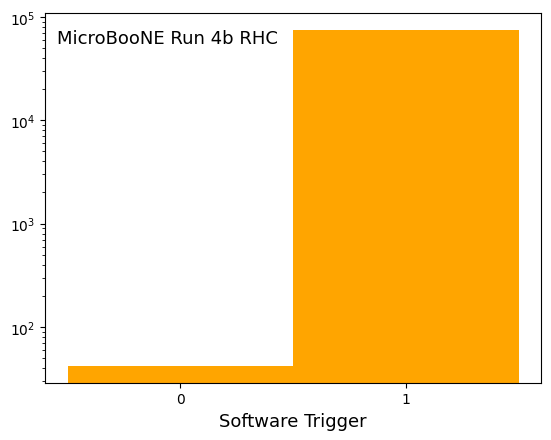

Signal passing SW trigger =  74774.03125
Signal failing SW trigger =  41.99422836303711


In [33]:
# Pass or fail software trigger plot for intrinsic nue
n = plt.hist(nue.query('is_signal==True').pandora_swtrig_pre, bins=[-0.5, 0.5, 1.5], color='orange', 
         weights=nue.query('is_signal==True')['totweight_intrinsic'])[0]

plt.xlabel("Software Trigger", fontsize=13)
plt.xticks([0,1])
plt.yscale("log")

plt.text(0.025, 0.92, "MicroBooNE Run 4b RHC",
        fontsize=13, transform=plt.gca().transAxes, horizontalalignment='left')

# plt.savefig('sw_trigger_run4brhc.pdf', transparent=False, bbox_inches='tight')

plt.show()

print('Signal passing SW trigger = ', n[1])
print('Signal failing SW trigger = ', n[0])

# Linear selection (Using `datasets`)

## Pandora Selection

In [34]:
# quality cuts
BDT_PRE_QUERY = '  pandora_swtrig_pre == 1'
BDT_PRE_QUERY += ' and pandora_slice_orig_pass_id == 1' 
BDT_PRE_QUERY += ' and 10<=pandora_reco_nu_vtx_sce_x<=246 and -106<=pandora_reco_nu_vtx_sce_y<=106 and 10<=pandora_reco_nu_vtx_sce_z<=1026'
BDT_PRE_QUERY += ' and pandora_contained_fraction > 0.9'

# signal definition - shower constraints
BDT_PRE_QUERY += ' and pandora_n_showers_contained == 1'

# signal definition - michel electron phase space constraint
BDT_PRE_QUERY += ' and pandora_shr_energy_tot_cali > 0.07'

# signal definition - track constraints
BDT_PRE_QUERY += ' and pandora_n_tracks_contained > 0'
BDT_PRE_QUERY += ' and pandora_trk_energy > 0.04'
BDT_LOOSE_CUTS = BDT_PRE_QUERY

# loose shower constraints
BDT_LOOSE_CUTS += ' and pandora_shrmoliereavg < 15'
# loose track constraints (including NuGraph variables)
BDT_LOOSE_CUTS += ' and pandora_trkpid < 0.35'
BDT_LOOSE_CUTS += ' and pandora_tksh_distance < 12'

In [85]:
# Calculate cumulative efficiency, purity, and efficiency*purity after each cut

# total_signal_generated: all the true signal events generated (before cuts)
# signal_selected: Signal events that pass the selection cuts
# total_selected: ALL events that pass the selection cuts (signal + background) 

# Define individual cuts in order
cuts = [
    ('pandora_swtrig_pre == 1', 'Software Trigger'),
    ('pandora_slice_orig_pass_id == 1', 'Slice Pass ID'),
    ("10<=pandora_reco_nu_vtx_sce_x<=246 and -106<=pandora_reco_nu_vtx_sce_y<=106 and 10<=pandora_reco_nu_vtx_sce_z<=1026", 'Reco in FV'),
    ('pandora_contained_fraction > 0.9', 'Contained Fraction > 0.9'),
    ## SIGNAL DEFINITION
    ('pandora_n_showers_contained == 1', 'N Showers Contained = 1'),
    ('pandora_shr_energy_tot_cali > 0.07', 'Shower Energy > 70 MeV'),
    ('pandora_n_tracks_contained > 0', 'N Tracks Contained > 0'),
    ('pandora_trk_energy > 0.04', 'Track Energy > 0.04'),
    ## BDT LOOSE CUTS - NOT VARIABLES BEING FED INTO THE BDT!
    ## Loose numu rejection
    ('pandora_trkpid < 0.35', 'Track PID Score < 0.35'),
    ## Loose neutral pion rejection,
    ('pandora_shrmoliereavg < 15', 'Average Shower Moliere Angle < 15 degrees'),
    ('pandora_tksh_distance < 12', 'Track-Shower Distance < 12 cm')
]

# Get total signal generated (before any cuts) (weighted to beam-on POT)
pandora_total_signal_generated = sum(generated_signal(ISRUN3, 'nu_e', [0,100], 0, 100)[0])

print("="*80)
print("CUMULATIVE SELECTION CUT ANALYSIS")
print("="*80)
print(f"Total Signal Generated: {pandora_total_signal_generated:.2f} events\n")

# Build cumulative query
cumulative_query = ""
for i, (cut, description) in enumerate(cuts):
    # Add current cut to cumulative query
    if i == 0:
        cumulative_query = cut
    else:
        cumulative_query += ' and ' + cut
    
    # Calculate signal selected (weighted to bean-on POT)
    pandora_signal_selected = np.nansum(datasets['infv'].query(cumulative_query + ' and is_signal==True')['totweight_data'])
    
    # Calculate total selected (signal + background from infv, outfv, and ext)
    pandora_total_selected = (np.nansum(datasets['infv'].query(cumulative_query)['totweight_data']) + 
                      np.nansum(datasets['outfv'].query(cumulative_query)['totweight_data']) + 
                      np.nansum(datasets['ext'].query(cumulative_query)['pot_scale']))
    
    # Calculate metrics
    efficiency = (pandora_signal_selected / pandora_total_signal_generated) * 100
    purity = (pandora_signal_selected / pandora_total_selected) * 100 if pandora_total_selected > 0 else 0
    eff_times_pur = (efficiency * purity) / 100
    
    # Print results
    print(f"Cut {i+1}: {description}")
    print(f"  Query: {cut}")
    print(f"  Signal Selected: {pandora_signal_selected:.2f}")
    print(f"  Total Selected: {pandora_total_selected:.2f}")
    print(f"  Efficiency: {efficiency:.2f}%")
    print(f"  Purity: {purity:.2f}%")
    print(f"  Efficiency × Purity: {eff_times_pur:.2f}%")
    print("-"*80)

print("\nFinal Selection Query:")
print(BDT_LOOSE_CUTS)

Adding pot_scale column using dirt & EXT tune....
CUMULATIVE SELECTION CUT ANALYSIS
Total Signal Generated: 743.50 events

Cut 1: Software Trigger
  Query: pandora_swtrig_pre == 1
  Signal Selected: 743.08
  Total Selected: 1350391.23
  Efficiency: 99.94%
  Purity: 0.06%
  Efficiency × Purity: 0.05%
--------------------------------------------------------------------------------
Cut 2: Slice Pass ID
  Query: pandora_slice_orig_pass_id == 1
  Signal Selected: 617.45
  Total Selected: 173958.66
  Efficiency: 83.05%
  Purity: 0.35%
  Efficiency × Purity: 0.29%
--------------------------------------------------------------------------------
Cut 3: Reco in FV
  Query: 10<=pandora_reco_nu_vtx_sce_x<=246 and -106<=pandora_reco_nu_vtx_sce_y<=106 and 10<=pandora_reco_nu_vtx_sce_z<=1026
  Signal Selected: 602.26
  Total Selected: 111054.64
  Efficiency: 81.00%
  Purity: 0.54%
  Efficiency × Purity: 0.44%
--------------------------------------------------------------------------------
Cut 4: Cont

/tmp/ipykernel_1447136/3094109040.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(cut_labels, ha='center', fontsize=15)


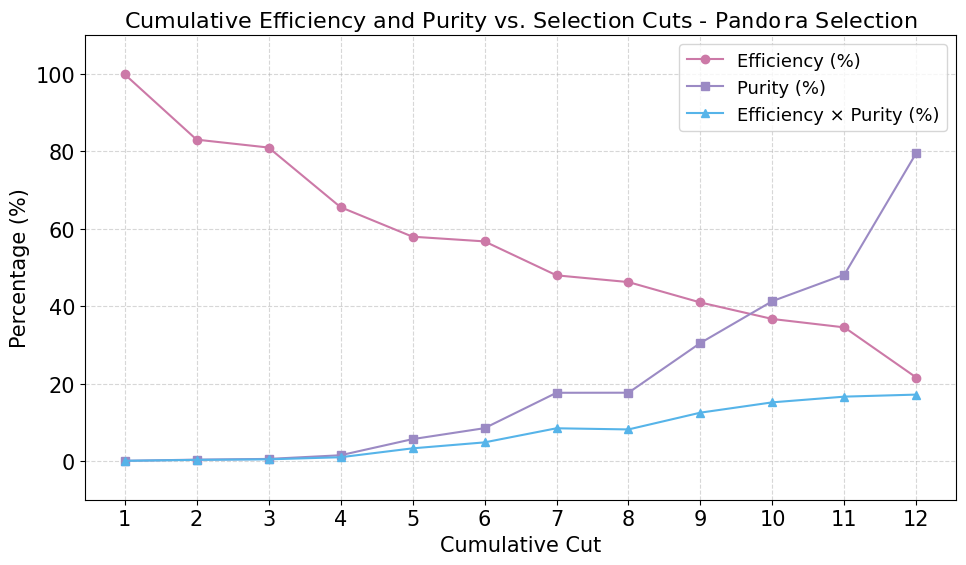

In [100]:
# --- Efficiency and Purity vs. Cumulative Cuts Figure ---
import matplotlib.pyplot as plt

# Store results for plotting
cut_labels = []
efficiencies = []
purities = []
eff_times_pur = []

cumulative_query = ""
for i, (cut, description) in enumerate(cuts):
    if i == 0:
        cumulative_query = cut
    else:
        cumulative_query += ' and ' + cut
    
    pandora_signal_selected = np.nansum(datasets['infv'].query(cumulative_query + ' and is_signal==True')['totweight_data'])
    pandora_total_selected = (
        np.nansum(datasets['infv'].query(cumulative_query)['totweight_data']) +
        np.nansum(datasets['outfv'].query(cumulative_query)['totweight_data']) +
        np.nansum(datasets['ext'].query(cumulative_query)['pot_scale'])
    )
    efficiency = (pandora_signal_selected / pandora_total_signal_generated) * 100
    purity = (pandora_signal_selected / pandora_total_selected) * 100 if pandora_total_selected > 0 else 0
    eff_times_pur_val = (efficiency * purity) / 100
    
    cut_labels.append(f'{i+1}')
    efficiencies.append(efficiency)
    purities.append(purity)
    eff_times_pur.append(eff_times_pur_val)

# Manually add final selection point
cut_labels.append('12')
efficiencies.append(21.55)
purities.append(79.65)
eff_times_pur.append(21.55 * 79.65 / 100)

# Plot
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(cut_labels, efficiencies, marker='o', label='Efficiency (%)', color='#CC79A7')
ax1.plot(cut_labels, purities, marker='s', label='Purity (%)', color='#9B8AC4')
ax1.plot(cut_labels, eff_times_pur, marker='^', label='Efficiency × Purity (%)', color='#56B4E9')

ax1.set_ylim(-10, 110)

ax1.set_ylabel('Percentage (%)', fontsize = 15)
ax1.set_xlabel('Cumulative Cut', fontsize = 15)
ax1.set_xticklabels(cut_labels, ha='center', fontsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.set_title(r'Cumulative Efficiency and Purity vs. Selection Cuts - $\mathtt{Pandora}$ Selection', fontsize=16)
ax1.legend(fontsize = 13, loc = 'upper right')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('eff_pur_cumulative_cuts_pandora.pdf', transparent=False, bbox_inches='tight')

plt.show()

## WireCell Selection

In [37]:
def populate_reco_counters(wc3_Ntrack,
                           wc3_reco_pdg,
                           wc3_reco_mother,
                           wc3_reco_startMomentum,
                           e_thr=0.07,
                           proton_thr=0.04,
                           pi_thr=0.04):

    # Initialise counters
    reco_electron = 0
    reco_proton = 0
    reco_mu = 0
    reco_pi0 = 0
    reco_pi = 0

    for i in range(wc3_Ntrack):

        pdg    = int(wc3_reco_pdg[i])
        mother = int(wc3_reco_mother[i])

        # Must come from neutrino
        if mother != 0:
            continue

        # Skip photons + neutrons
        if pdg in (22, 2112):
            continue

        # Momentum magnitude (assuming index 3 stores TOTAL energy)
        energy = wc3_reco_startMomentum[i][3]

        # Electron
        if abs(pdg) == 11 and energy - 0.000511 > e_thr:
            reco_electron += 1

        # Proton
        elif pdg == 2212 and energy - 0.938 > proton_thr:
            reco_proton += 1

        # Muon -> numu
        elif abs(pdg) == 13:
            reco_mu += 1

        # Neutral pion
        elif pdg == 111:
            reco_pi0 += 1

        # Charged pion 
        elif abs(pdg) == 211 and energy - 0.140 > pi_thr:
            reco_pi += 1

        # ignore everything else

    return reco_electron, reco_proton, reco_mu, reco_pi0, reco_pi

In [38]:
# Check which datasets need reco columns and add them
reco_columns = ["reco_electron", "reco_proton", "reco_mu", "reco_pi0", "reco_pi"]

for dataset_name, dataset_df in [("infv", infv), ("outfv", outfv), ("ext", ext)]:
    if not dataset_df.empty:
        if 'reco_electron' not in dataset_df.columns:
            print(f"Adding reco columns to {dataset_name}...")
            
            # Use the proper particle counting function for all datasets
            if 'wc3_reco_mother' in dataset_df.columns:
                print(f"  Computing reco columns using WC3 data for {dataset_name}...")
                
                print(f"  Computing reco columns using optimized multiprocessing for {dataset_name}...")
                
                # Use multiprocessing for fast parallel computation
                from multiprocessing import Pool, cpu_count
                import numpy as np
                
                def compute_reco_batch(args):
                    start_idx, end_idx, ntrack_arr, pdg_arr, mother_arr, momentum_arr = args
                    batch_results = []
                    for i in range(start_idx, end_idx):
                        e, p, mu, pi0, pi = populate_reco_counters(
                            int(ntrack_arr[i]),
                            pdg_arr[i],
                            mother_arr[i],
                            momentum_arr[i]
                        )
                        batch_results.append([e, p, mu, pi0, pi])
                    return batch_results
                
                # Extract arrays
                ntrack_array = dataset_df['wc3_reco_Ntrack'].values
                pdg_array = dataset_df['wc3_reco_pdg'].values
                mother_array = dataset_df['wc3_reco_mother'].values  
                momentum_array = dataset_df['wc3_reco_startMomentum'].values
                
                n_rows = len(dataset_df)
                n_processes = min(6, cpu_count())  # Use up to 6 processes for speed
                batch_size = max(5000, n_rows // n_processes)  # Larger batches for efficiency
                
                # Prepare batches for multiprocessing
                batches = []
                for start in range(0, n_rows, batch_size):
                    end = min(start + batch_size, n_rows)
                    batches.append((start, end, ntrack_array, pdg_array, mother_array, momentum_array))
                
                print(f"  Processing {n_rows} rows with {len(batches)} batches using {n_processes} processes...")
                
                # Process in parallel
                with Pool(n_processes) as pool:
                    batch_results = pool.map(compute_reco_batch, batches)
                
                # Combine results
                all_results = []
                for batch in batch_results:
                    all_results.extend(batch)
                
                # Convert to arrays and assign
                results_array = np.array(all_results)
                dataset_df['reco_electron'] = results_array[:, 0]
                dataset_df['reco_proton'] = results_array[:, 1]
                dataset_df['reco_mu'] = results_array[:, 2]
                dataset_df['reco_pi0'] = results_array[:, 3]
                dataset_df['reco_pi'] = results_array[:, 4]
            else:
                print(f"  Warning: {dataset_name} missing wc3_reco_mother column, adding zero columns")
                for col in reco_columns:
                    dataset_df[col] = 0
            
            print(f"✓ Added reco columns to {dataset_name}")
        else:
            print(f"✓ {dataset_name} already has reco columns")
    else:
        print(f"⚠ Skipping {dataset_name}: empty dataset")

Adding reco columns to infv...
  Computing reco columns using WC3 data for infv...
  Computing reco columns using optimized multiprocessing for infv...
  Processing 363774 rows with 6 batches using 6 processes...
✓ Added reco columns to infv
Adding reco columns to outfv...
  Computing reco columns using WC3 data for outfv...
  Computing reco columns using optimized multiprocessing for outfv...
  Processing 427668 rows with 6 batches using 6 processes...


/tmp/ipykernel_1447136/1200605837.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_df['reco_electron'] = results_array[:, 0]
/tmp/ipykernel_1447136/1200605837.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_df['reco_proton'] = results_array[:, 1]
/tmp/ipykernel_1447136/1200605837.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pand

✓ Added reco columns to outfv
Adding reco columns to ext...
  Computing reco columns using WC3 data for ext...
  Computing reco columns using optimized multiprocessing for ext...
  Processing 1941196 rows with 7 batches using 6 processes...


/tmp/ipykernel_1447136/1200605837.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_df['reco_electron'] = results_array[:, 0]
/tmp/ipykernel_1447136/1200605837.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_df['reco_proton'] = results_array[:, 1]
/tmp/ipykernel_1447136/1200605837.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pand

✓ Added reco columns to ext


In [39]:
# Preselection
WC_PRE_QUERY = reco_in_fv_query # Reconstructed vertex must be within Pandora-value FV
WC_PRE_QUERY += ' and wc2_numu_cc_flag >= 0' # Valid numu CC flag
WC_PRE_QUERY += ' and wc1_match_isFC == 1' # Event must be fully contained

# Signal definition constraints - protons, electrons, and charged pions have energy thresholds added 
WC_PRE_QUERY += ' and reco_electron == 1' # One reconstructed electron
WC_PRE_QUERY += ' and reco_proton > 0' # At least one reconstructed proton
WC_PRE_QUERY += ' and reco_mu == 0' # No reconstructed muons
WC_PRE_QUERY += ' and reco_pi == 0' # No reconstructed charged pions
WC_PRE_QUERY += ' and reco_pi0 == 0' # No reconstructed pi0s

# Other
WC_PRE_QUERY += ' and wc2_nue_score > 7' # Electron neutrino BDT score cut


In [104]:
# Calculate cumulative efficiency, purity, and efficiency*purity after each cut

# total_signal_generated: all the true signal events generated (before cuts)
# signal_selected: Signal events that pass the selection cuts
# total_selected: ALL events that pass the selection cuts (signal + background) 

# Define individual cuts in order
cuts = [
    (reco_in_fv_query, 'Reco in FV'),
    ('wc2_numu_cc_flag >= 0', 'numu CC Flag >= 0'),
    ('wc1_match_isFC == 1', 'Matched is Fully Contained'),
    ## SIGNAL DEFINITION
    ('reco_electron == 1', 'One Reconstructed Electron'),
    ('reco_proton > 0', 'At Least One Reconstructed Proton'),
    ('reco_mu == 0', 'No Reconstructed Muons'),
    ('reco_pi == 0', 'No Reconstructed Charged Pions'),
    ('reco_pi0 == 0', 'No Reconstructed Pi0s'),
    ('wc2_nue_score > 7', 'Nue Score > 7')
]

# Get total signal generated (before any cuts) (weighted to beam-on POT)
wc_total_signal_generated = sum(generated_signal(ISRUN3, 'nu_e', [0,100], 0, 100)[0])

print("="*80)
print("CUMULATIVE SELECTION CUT ANALYSIS")
print("="*80)
print(f"Total Signal Generated: {wc_total_signal_generated:.2f} events\n")

# Build cumulative query
cumulative_query = ""
for i, (cut, description) in enumerate(cuts):
    # Add current cut to cumulative query
    if i == 0:
        cumulative_query = cut
    else:
        cumulative_query += ' and ' + cut
    
    # Calculate signal selected (weighted to bean-on POT)
    wc_signal_selected = np.nansum(datasets['infv'].query(cumulative_query + ' and is_signal==True')['totweight_data'])
    
    # Calculate total selected (signal + background from infv, outfv, and ext)
    wc_total_selected = (np.nansum(datasets['infv'].query(cumulative_query)['totweight_data']) + 
                      np.nansum(datasets['outfv'].query(cumulative_query)['totweight_data']) + 
                      np.nansum(datasets['ext'].query(cumulative_query)['pot_scale']))
    
    # Calculate metrics
    efficiency = (wc_signal_selected / wc_total_signal_generated) * 100
    purity = (wc_signal_selected / wc_total_selected) * 100 if wc_total_selected > 0 else 0
    eff_times_pur = (efficiency * purity) / 100
    
    # Print results
    print(f"Cut {i+1}: {description}")
    print(f"  Query: {cut}")
    print(f"  Signal Selected: {wc_signal_selected:.2f}")
    print(f"  Total Selected: {wc_total_selected:.2f}")
    print(f"  Efficiency: {efficiency:.2f}%")
    print(f"  Purity: {purity:.2f}%")
    print(f"  Efficiency × Purity: {eff_times_pur:.2f}%")
    print("-"*80)

print("\nFinal Selection Query:")
print(WC_PRE_QUERY)

Adding pot_scale column using dirt & EXT tune....
CUMULATIVE SELECTION CUT ANALYSIS
Total Signal Generated: 743.50 events

Cut 1: Reco in FV
  Query: 10<=wc3_reco_nuvtxX<=246 and -106<=wc3_reco_nuvtxY<=106 and 10<=wc3_reco_nuvtxZ<=1026
  Signal Selected: 646.49
  Total Selected: 48960.60
  Efficiency: 86.95%
  Purity: 1.32%
  Efficiency × Purity: 1.15%
--------------------------------------------------------------------------------
Cut 2: numu CC Flag >= 0
  Query: wc2_numu_cc_flag >= 0
  Signal Selected: 646.18
  Total Selected: 45837.43
  Efficiency: 86.91%
  Purity: 1.41%
  Efficiency × Purity: 1.23%
--------------------------------------------------------------------------------
Cut 3: Matched is Fully Contained
  Query: wc1_match_isFC == 1
  Signal Selected: 441.82
  Total Selected: 18524.42
  Efficiency: 59.42%
  Purity: 2.39%
  Efficiency × Purity: 1.42%
--------------------------------------------------------------------------------
Cut 4: One Reconstructed Electron
  Query: re

/tmp/ipykernel_1447136/2461981563.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(cut_labels, ha='center', fontsize=15)


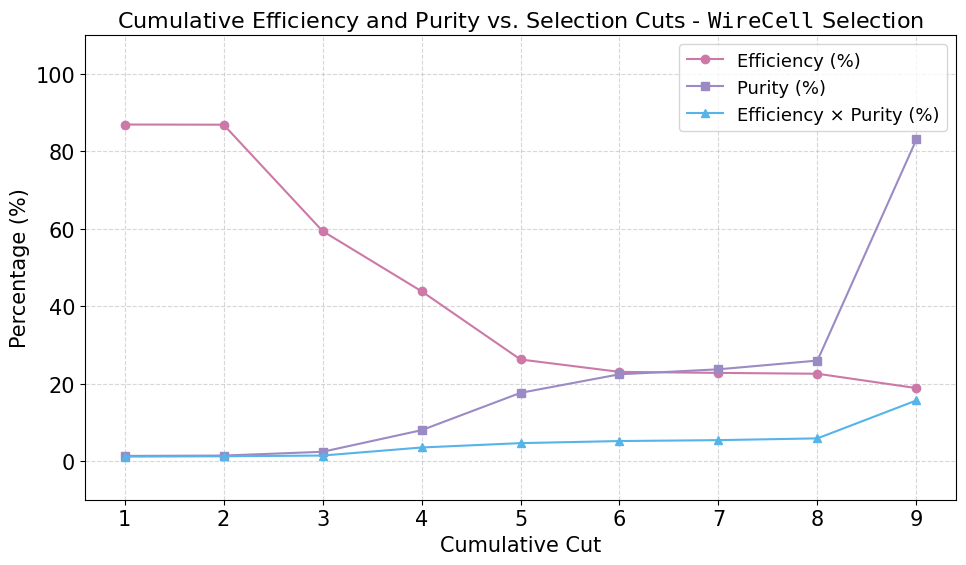

In [106]:
# --- Efficiency and Purity vs. Cumulative Cuts Figure ---
import matplotlib.pyplot as plt

# Store results for plotting
cut_labels = []
efficiencies = []
purities = []
eff_times_pur = []

cumulative_query = ""
for i, (cut, description) in enumerate(cuts):
    if i == 0:
        cumulative_query = cut
    else:
        cumulative_query += ' and ' + cut
    
      # Calculate signal selected (weighted to bean-on POT)
    wc_signal_selected = np.nansum(datasets['infv'].query(cumulative_query + ' and is_signal==True')['totweight_data'])
    
    # Calculate total selected (signal + background from infv, outfv, and ext)
    wc_total_selected = (np.nansum(datasets['infv'].query(cumulative_query)['totweight_data']) + 
                      np.nansum(datasets['outfv'].query(cumulative_query)['totweight_data']) + 
                      np.nansum(datasets['ext'].query(cumulative_query)['pot_scale']))
    
    # Calculate metrics
    efficiency = (wc_signal_selected / wc_total_signal_generated) * 100
    purity = (wc_signal_selected / wc_total_selected) * 100 if wc_total_selected > 0 else 0
    eff_times_pur_val = (efficiency * purity) / 100
    
    cut_labels.append(f'{i+1}')
    efficiencies.append(efficiency)
    purities.append(purity)
    eff_times_pur.append(eff_times_pur_val)

# Plot
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(cut_labels, efficiencies, marker='o', label='Efficiency (%)', color='#CC79A7')
ax1.plot(cut_labels, purities, marker='s', label='Purity (%)', color='#9B8AC4')
ax1.plot(cut_labels, eff_times_pur, marker='^', label='Efficiency × Purity (%)', color='#56B4E9')

ax1.set_ylim(-10, 110)

ax1.set_ylabel('Percentage (%)', fontsize = 15)
ax1.set_xlabel('Cumulative Cut', fontsize = 15)
ax1.set_xticklabels(cut_labels, ha='center', fontsize=15)
ax1.tick_params(axis='y', labelsize=15)
ax1.set_title(r'Cumulative Efficiency and Purity vs. Selection Cuts - $\mathtt{WireCell}$ Selection', fontsize=16)
ax1.legend(fontsize = 13, loc = 'upper right')
ax1.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('eff_pur_cumulative_cuts_wirecell.pdf', transparent=False, bbox_inches='tight')

plt.show()

# Creating the `datasets_bdt_new` Dataset

In [41]:
# Create datasets_bdt_new dictionary with the updated datasets
datasets_bdt_new = {
    'infv': infv,
    'outfv': outfv, 
    'ext': ext
}

print("Successfully created datasets_bdt_new with keys:", list(datasets_bdt_new.keys()))
print("Dataset sizes:")
for key, df in datasets_bdt_new.items():
    print(f"  {key}: {len(df)} events")

Successfully created datasets_bdt_new with keys: ['infv', 'outfv', 'ext']
Dataset sizes:
  infv: 363774 events
  outfv: 427668 events
  ext: 1941196 events


In [42]:
# Clean datasets_bdt_new for extreme values (NaN cleaning)
# This ensures both Pandora and WireCell selections use the same cleaned dataset
print("Cleaning datasets_bdt_new for extreme values...")

for dataset_name, dataset_df in datasets_bdt_new.items():
    print(f"\nProcessing {dataset_name} dataset...")
    print(f"  Total events before cleaning: {len(dataset_df)}")
    
    # Clean datasets for BDT (handle extreme values)
    extreme_count = 0
    for column in training_parameters:
        if column in dataset_df.columns:
            # Count extreme values before cleaning
            extreme_mask = (dataset_df[column] < -1.0e37) | (dataset_df[column] > 1.0e37)
            column_extreme_count = extreme_mask.sum()
            if column_extreme_count > 0:
                extreme_count += column_extreme_count
                print(f"    {column}: {column_extreme_count} extreme values found")
                # Replace extreme values with NaN
                dataset_df.loc[extreme_mask, column] = np.nan
    
    print(f"  Total extreme values replaced with NaN: {extreme_count}")
    print(f"  Events after cleaning: {len(dataset_df)}")

print("\n✓ All datasets cleaned for extreme values")

Cleaning datasets_bdt_new for extreme values...

Processing infv dataset...
  Total events before cleaning: 363774
    pandora_shr_tkfit_dedx_Y: 236317 extreme values found
    pandora_shr_tkfit_gap10_dedx_Y: 236317 extreme values found
    pandora_shr_tkfit_2cm_dedx_Y: 236317 extreme values found
    pandora_shrmoliereavg: 217249 extreme values found
    pandora_tksh_distance: 51620 extreme values found
    pandora_trkshrhitdist2: 51620 extreme values found
  Total extreme values replaced with NaN: 1029440
  Events after cleaning: 363774

Processing outfv dataset...
  Total events before cleaning: 427668
    pandora_shr_tkfit_dedx_Y: 403151 extreme values found
    pandora_shr_tkfit_gap10_dedx_Y: 403151 extreme values found
    pandora_shr_tkfit_2cm_dedx_Y: 403151 extreme values found
    pandora_shrmoliereavg: 397300 extreme values found
    pandora_tksh_distance: 225751 extreme values found
    pandora_trkshrhitdist2: 225751 extreme values found
  Total extreme values replaced with 

In [43]:
# Needed for Pandora selection
bdt_score_cut = parameters(ISRUN3)['bdt_score_cut']
    
print("BDT SCORE THRESHOLD = "+str(bdt_score_cut))

selected_query = BDT_LOOSE_CUTS + ' and BDT_score>'+str(bdt_score_cut)
selected_signal_query = selected_query + ' and is_signal==True'

split = 1
bdt_model = xgb.Booster({'nthread': 4})
bdt_model.load_model(parameters(ISRUN3)['bdt_model'])

BDT SCORE THRESHOLD = 0.55


In [44]:
# Apply BDT model to datasets_bdt_new to add BDT_score column (WITH CORRECTED FEATURE ORDERING)
print("Adding BDT_score column to datasets_bdt_new (applying to ALL events)...")
print("Ensuring features are passed in the correct order expected by the BDT model...")

# Get the feature names from the loaded BDT model in the correct order
model_feature_names = bdt_model.feature_names
print(f"\nModel expects {len(model_feature_names)} features in this order:")
for i, feature in enumerate(model_feature_names):
    print(f"  {i+1}. {feature}")

for dataset_name, dataset_df in datasets_bdt_new.items():
    print(f"\nProcessing {dataset_name} dataset...")
    print(f"  Total events: {len(dataset_df)}")
    
    # Work with ALL events, not just those passing loose cuts
    df_temp = dataset_df.copy()
    
    # Create DataFrame with columns in the EXACT order the model expects
    bdt_df = pd.DataFrame()
    missing_features = []
    
    for feature_name in model_feature_names:
        # Map model feature name to pandora-prefixed column
        pandora_col = f'pandora_{feature_name}'
        
        if pandora_col in df_temp.columns:
            # Add column in the correct order
            bdt_df[feature_name] = df_temp[pandora_col]
        else:
            print(f"  WARNING: Missing column {pandora_col}, filling with NaN")
            bdt_df[feature_name] = np.nan
            missing_features.append(pandora_col)
    
    if len(bdt_df.columns) > 0:
        # Verify column order matches model expectations
        if list(bdt_df.columns) == model_feature_names:
            print(f"  ✓ Feature order verified: columns match model expectations")
        else:
            print(f"  ⚠ WARNING: Feature order mismatch!")
        
        # Create DMatrix with explicit feature names to ensure correct ordering
        df_test = xgb.DMatrix(data=bdt_df, feature_names=model_feature_names)
        
        # Apply the BDT model to ALL events
        preds = bdt_model.predict(df_test)
        
        # Add BDT scores to the dataset
        dataset_df['BDT_score'] = preds
        
        print(f"  BDT scores added: {len(preds)} events scored (ALL events)")
        
        if missing_features:
            print(f"  Note: {len(missing_features)} features were missing and filled with NaN")
    else:
        print(f"  ERROR: No valid BDT columns found")
        dataset_df['BDT_score'] = np.nan

print("\n✓ BDT_score column successfully added to all events in datasets_bdt_new")
print("✓ Feature ordering has been corrected to match the BDT model's expectations")

Adding BDT_score column to datasets_bdt_new (applying to ALL events)...
Ensuring features are passed in the correct order expected by the BDT model...

Model expects 14 features in this order:
  1. shr_tkfit_dedx_Y
  2. shr_tkfit_gap10_dedx_Y
  3. shr_tkfit_2cm_dedx_Y
  4. trkpid
  5. pfng2hipfrac
  6. pfng2hipavrg
  7. ng2hip_r1cm
  8. ng2hip_r10cm
  9. pfng2shrfrac
  10. pfng2shravrg
  11. shrmoliereavg
  12. subcluster
  13. tksh_distance
  14. trkshrhitdist2

Processing infv dataset...
  Total events: 363774
  ✓ Feature order verified: columns match model expectations


/tmp/ipykernel_1447136/3188661350.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_df['BDT_score'] = preds


  BDT scores added: 363774 events scored (ALL events)

Processing outfv dataset...
  Total events: 427668
  ✓ Feature order verified: columns match model expectations


/tmp/ipykernel_1447136/3188661350.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_df['BDT_score'] = preds


  BDT scores added: 427668 events scored (ALL events)

Processing ext dataset...
  Total events: 1941196
  ✓ Feature order verified: columns match model expectations
  BDT scores added: 1941196 events scored (ALL events)

✓ BDT_score column successfully added to all events in datasets_bdt_new
✓ Feature ordering has been corrected to match the BDT model's expectations


In [45]:
# Verify BDT_score column was added successfully
print("Verification of BDT_score column:")
for key, df in datasets_bdt_new.items():
    has_bdt_score = 'BDT_score' in df.columns
    if has_bdt_score:
        score_stats = df['BDT_score'].describe()
        n_valid_scores = df['BDT_score'].notna().sum()
        print(f"  {key}: ✓ BDT_score exists, {n_valid_scores} valid scores")
        print(f"    Score range: {score_stats['min']:.4f} to {score_stats['max']:.4f}")
    else:
        print(f"  {key}: ✗ BDT_score missing")

Verification of BDT_score column:
  infv: ✓ BDT_score exists, 363774 valid scores
    Score range: 0.0075 to 0.9357
  outfv: ✓ BDT_score exists, 427668 valid scores
    Score range: 0.0083 to 0.8953
  ext: ✓ BDT_score exists, 1941196 valid scores
    Score range: 0.0090 to 0.8543


In [46]:
# # Check the column name mapping issue
# print("Training parameters expected by BDT model:")
# for param in training_parameters:
#     print(f"  {param}")

# print(f"\nColumns available in infv dataset:")
# pandora_cols = [col for col in datasets_bdt_new['infv'].columns if any(param in col for param in training_parameters)]
# for col in sorted(pandora_cols):
#     print(f"  {col}")

# print("\nColumn mapping needed:")
# pandora_to_bdt_mapping = {}
# for param in training_parameters:
#     # Look for pandora_ prefixed version
#     pandora_col = f"pandora_{param}"
#     if pandora_col in datasets_bdt_new['infv'].columns:
#         pandora_to_bdt_mapping[pandora_col] = param
#         print(f"  {pandora_col} -> {param}")
#     else:
#         print(f"  WARNING: No matching column found for {param}")

# print(f"\nMapping dictionary: {pandora_to_bdt_mapping}")

In [47]:
print("Training parameters expected by BDT model:")
for param in training_parameters:
    print(f"  {param}")

print(f"\nColumns available in infv dataset:")
pandora_cols = [col for col in datasets_bdt_new['infv'].columns if any(param in col for param in training_parameters)]
for col in sorted(pandora_cols):
    print(f"  {col}")

print("\nColumn mapping needed:")
pandora_to_bdt_mapping = {}
for param in training_parameters:
    # Check if the parameter (which already has pandora_ prefix) exists
    if param in datasets_bdt_new['infv'].columns:
        pandora_to_bdt_mapping[param] = param
        print(f"  {param} -> {param}")
    else:
        print(f"  WARNING: No matching column found for {param}")

print(f"\nMapping dictionary: {pandora_to_bdt_mapping}")

Training parameters expected by BDT model:
  pandora_shr_tkfit_dedx_Y
  pandora_shr_tkfit_gap10_dedx_Y
  pandora_shr_tkfit_2cm_dedx_Y
  pandora_trkpid
  pandora_pfng2hipfrac
  pandora_pfng2hipavrg
  pandora_ng2hip_r1cm
  pandora_ng2hip_r10cm
  pandora_pfng2shrfrac
  pandora_pfng2shravrg
  pandora_shrmoliereavg
  pandora_subcluster
  pandora_tksh_distance
  pandora_trkshrhitdist2

Columns available in infv dataset:
  pandora_ng2hip_r10cm
  pandora_ng2hip_r1cm
  pandora_pfng2hipavrg
  pandora_pfng2hipfrac
  pandora_pfng2shravrg
  pandora_pfng2shrfrac
  pandora_shr_tkfit_2cm_dedx_Y
  pandora_shr_tkfit_dedx_Y
  pandora_shr_tkfit_gap10_dedx_Y
  pandora_shrmoliereavg
  pandora_subcluster
  pandora_tksh_distance
  pandora_trkpid
  pandora_trkshrhitdist2

Column mapping needed:
  pandora_shr_tkfit_dedx_Y -> pandora_shr_tkfit_dedx_Y
  pandora_shr_tkfit_gap10_dedx_Y -> pandora_shr_tkfit_gap10_dedx_Y
  pandora_shr_tkfit_2cm_dedx_Y -> pandora_shr_tkfit_2cm_dedx_Y
  pandora_trkpid -> pandora_trkpid

# Further Selection (Using `datasets_bdt_new`)

In [48]:
# Apply Pandora selection and compare with WC selection
print("=== APPLYING PANDORA SELECTION TO PANDORA DATASETS ===")

print(f"Pandora selection query: {selected_query}")
print(f"Pandora signal query: {selected_signal_query}")

# Apply Pandora selection to get event IDs
pandora_selected_events = []

for dataset_name, dataset_df in datasets_bdt_new.items():
    print(f"\nProcessing {dataset_name} with Pandora selection...")
    
    try:
        # Apply Pandora selection
        passing_events = dataset_df.query(selected_query)
        
        if len(passing_events) > 0:
            # Extract run, subrun, and event columns for Pandora selection
            event_ids = passing_events[['pandora_run', 'pandora_sub', 'pandora_evt']].copy()
            pandora_selected_events.append(event_ids)
            print(f"  Found {len(event_ids)} events passing Pandora selection")
            
            # Also check signal events
            try:
                signal_events = dataset_df.query(selected_signal_query)
                print(f"  Signal events: {len(signal_events)}")
            except:
                print(f"  Could not evaluate signal query")
        else:
            print(f"  No events found passing BDT selection")
            
    except Exception as e:
        print(f"  Error applying Pandora selection to {dataset_name}: {e}")

# Combine Pandora selected event IDs
if pandora_selected_events:
    pandora_passing_event_ids = pd.concat(pandora_selected_events, ignore_index=True)
    print(f"\nTotal Pandora-selected events across all datasets: {len(pandora_passing_event_ids)}")
    
    # Save Pandora selection results
    pandora_output_filename = f"pandora_selected_events_threshold_{bdt_score_cut}.csv"
    pandora_passing_event_ids.to_csv(pandora_output_filename, index=False)
    print(f"Pandora-selected event IDs saved to: {pandora_output_filename}")
    
    # Create event keys for comparison with WC selection
    pandora_selected_keys = set(pandora_passing_event_ids['pandora_run'].astype(str) + '_' + 
                           pandora_passing_event_ids['pandora_sub'].astype(str) + '_' + 
                           pandora_passing_event_ids['pandora_evt'].astype(str))
    
    print(f"First 10 Pandora-selected events:")
    print(pandora_passing_event_ids.head(10))
    
else:
    print("No Pandora-selected events found!")
    pandora_selected_keys = set()
    
print(f"\nPandora selection complete!")
print(f"- Pandora events: {len(pandora_selected_keys):,}")

=== APPLYING PANDORA SELECTION TO PANDORA DATASETS ===
Pandora selection query:   pandora_swtrig_pre == 1 and pandora_slice_orig_pass_id == 1 and 10<=pandora_reco_nu_vtx_sce_x<=246 and -106<=pandora_reco_nu_vtx_sce_y<=106 and 10<=pandora_reco_nu_vtx_sce_z<=1026 and pandora_contained_fraction > 0.9 and pandora_n_showers_contained == 1 and pandora_shr_energy_tot_cali > 0.07 and pandora_n_tracks_contained > 0 and pandora_trk_energy > 0.04 and pandora_shrmoliereavg < 15 and pandora_trkpid < 0.35 and pandora_tksh_distance < 12 and BDT_score>0.55
Pandora signal query:   pandora_swtrig_pre == 1 and pandora_slice_orig_pass_id == 1 and 10<=pandora_reco_nu_vtx_sce_x<=246 and -106<=pandora_reco_nu_vtx_sce_y<=106 and 10<=pandora_reco_nu_vtx_sce_z<=1026 and pandora_contained_fraction > 0.9 and pandora_n_showers_contained == 1 and pandora_shr_energy_tot_cali > 0.07 and pandora_n_tracks_contained > 0 and pandora_trk_energy > 0.04 and pandora_shrmoliereavg < 15 and pandora_trkpid < 0.35 and pandora_tk

In [49]:
# Apply WireCell (WC_PRE_QUERY) selection and prepare for comparison with Pandora selection
print("=== APPLYING WIRECELL PRE-SELECTION TO DATASETS ===")

print(f"WireCell pre-selection query: {WC_PRE_QUERY}")

# Apply WireCell selection to get event IDs
wc_selected_events = []

for dataset_name, dataset_df in datasets_bdt_new.items():
    print(f"\nProcessing {dataset_name} with WireCell pre-selection...")
    
    try:
        # Apply the WireCell pre-query
        passing_events = dataset_df.query(WC_PRE_QUERY)
        
        if len(passing_events) > 0:
            # Extract run, subrun, and event columns for WireCell selection
            event_ids = passing_events[['pandora_run', 'pandora_sub', 'pandora_evt']].copy()
            wc_selected_events.append(event_ids)
            print(f"  Found {len(event_ids)} events passing WC_PRE_QUERY")
        else:
            print(f"  No events found passing WC_PRE_QUERY")
            
    except Exception as e:
        print(f"  Error applying WC_PRE_QUERY to {dataset_name}: {e}")

# Combine WireCell selected event IDs
if wc_selected_events:
    wc_passing_event_ids = pd.concat(wc_selected_events, ignore_index=True)
    print(f"\nTotal WireCell-preselected events across all datasets: {len(wc_passing_event_ids)}")
    
    # # Save WireCell selection results
    # wc_output_filename = "wc_prequery_passing_event_ids.csv"
    # wc_passing_event_ids.to_csv(wc_output_filename, index=False)
    # print(f"WireCell pre-selection event IDs saved to: {wc_output_filename}")
    
    # Create event keys for comparison with Pandora selection
    wc_selected_keys = set(
        wc_passing_event_ids['pandora_run'].astype(str) + '_' +
        wc_passing_event_ids['pandora_sub'].astype(str) + '_' +
        wc_passing_event_ids['pandora_evt'].astype(str)
    )

    print(f"\nFirst 10 WireCell-preselected events:")
    print(wc_passing_event_ids.head(10))
    
else:
    print("No WireCell-preselected events found!")
    wc_selected_keys = set()

print(f"\nWireCell pre-selection complete!")
print(f"- WireCell events: {len(wc_selected_keys):,}")

=== APPLYING WIRECELL PRE-SELECTION TO DATASETS ===
WireCell pre-selection query: 10<=wc3_reco_nuvtxX<=246 and -106<=wc3_reco_nuvtxY<=106 and 10<=wc3_reco_nuvtxZ<=1026 and wc2_numu_cc_flag >= 0 and wc1_match_isFC == 1 and reco_electron == 1 and reco_proton > 0 and reco_mu == 0 and reco_pi == 0 and reco_pi0 == 0 and wc2_nue_score > 7

Processing infv with WireCell pre-selection...
  Found 13898 events passing WC_PRE_QUERY

Processing outfv with WireCell pre-selection...
  Found 131 events passing WC_PRE_QUERY

Processing ext with WireCell pre-selection...
  No events found passing WC_PRE_QUERY

Total WireCell-preselected events across all datasets: 14029

First 10 WireCell-preselected events:
   pandora_run  pandora_sub  pandora_evt
0        20214          426        21332
1        20732          212        10614
2        20730          331        16557
3        20652          137         6859
4        20386          365        18300
5        21140          128         6431
6        205

# Combined Analysis: BDT-Scored Pandora + WireCell Independent Selections

Fix the combined analysis to both use datasets_bdt_new (which they both are able to access)

In [50]:
# Pandora final query (BDT loose cuts + BDT threshold)
pandora_final_query = BDT_LOOSE_CUTS + ' and BDT_score>'+str(bdt_score_cut)

# Signal selected (POT-weighted)
pandora_signal_selected = np.nansum(datasets_bdt_new['infv'].query(pandora_final_query + ' and is_signal==True')['totweight_data'])

# Total selected = signal + background
pandora_total_selected = (
    np.nansum(datasets_bdt_new['infv'].query(pandora_final_query)['totweight_data']) +
    np.nansum(datasets_bdt_new['outfv'].query(pandora_final_query)['totweight_data']) +
    np.nansum(datasets_bdt_new['ext'].query(pandora_final_query)['pot_scale'])
)

# Efficiency & purity
pandora_eff = 100 * pandora_signal_selected / pandora_total_signal_generated
pandora_pur = 100 * pandora_signal_selected / pandora_total_selected if pandora_total_selected > 0 else 0

print("\n=== PANDORA FINAL SELECTION ===")
print(f"Signal selected: {pandora_signal_selected:.2f}")
print(f"Total selected:  {pandora_total_selected:.2f}")
print(f"Efficiency:      {pandora_eff:.2f}%")
print(f"Purity:          {pandora_pur:.2f}%")


=== PANDORA FINAL SELECTION ===
Signal selected: 160.21
Total selected:  201.13
Efficiency:      21.55%
Purity:          79.65%


In [51]:
# WireCell final query (all cuts applied)
WC_FINAL_QUERY = WC_PRE_QUERY

# Signal selected (weighted)
wc_signal_selected = np.nansum(datasets_bdt_new['infv'].query(WC_FINAL_QUERY + ' and is_signal==True')['totweight_data'])

# Total selected
wc_total_selected = (
    np.nansum(datasets_bdt_new['infv'].query(WC_FINAL_QUERY)['totweight_data']) +
    np.nansum(datasets_bdt_new['outfv'].query(WC_FINAL_QUERY)['totweight_data']) +
    np.nansum(datasets_bdt_new['ext'].query(WC_FINAL_QUERY)['pot_scale'])
)

# Efficiency & purity
wc_eff = 100 * wc_signal_selected / wc_total_signal_generated
wc_pur = 100 * wc_signal_selected / wc_total_selected if wc_total_selected > 0 else 0

print("\n=== WIRECELL FINAL SELECTION ===")
print(f"Signal selected: {wc_signal_selected:.2f}")
print(f"Total selected:  {wc_total_selected:.2f}")
print(f"Efficiency:      {wc_eff:.2f}%")
print(f"Purity:          {wc_pur:.2f}%")


=== WIRECELL FINAL SELECTION ===
Signal selected: 140.12
Total selected:  168.63
Efficiency:      18.85%
Purity:          83.10%


# Unified `Pandora` and `WireCell` Selection

In [52]:
# Create union of Pandora and WireCell selected events using proper selection logic
print("=== CREATING UNION OF PANDORA AND WIRECELL SELECTIONS ===")

# Apply selection logic directly to datasets (corrected approach)
datasets_union = {}

# Track statistics for summary
pandora_total, wc_total, union_total = 0, 0, 0
overlap_count = 0
pandora_only_count = 0
wc_only_count = 0

for dataset_name, df in datasets_bdt_new.items():
    print(f"\nProcessing {dataset_name}...")
    
    # Apply Pandora selection
    pandora_mask = pd.Series(False, index=df.index)
    try:
        pandora_selected = df.query(pandora_final_query)
        pandora_mask = df.index.isin(pandora_selected.index)
        pandora_count = pandora_mask.sum()
    except:
        pandora_count = 0
    
    # Apply WireCell selection  
    wc_mask = pd.Series(False, index=df.index)
    try:
        wc_selected = df.query(WC_PRE_QUERY) 
        wc_mask = df.index.isin(wc_selected.index)
        wc_count = wc_mask.sum()
    except:
        wc_count = 0
    
    # Union: events that pass EITHER selection (OR logic)
    union_mask = pandora_mask | wc_mask
    union_count = union_mask.sum()
    
    # Track overlap and individual contributions
    overlap_mask = pandora_mask & wc_mask
    dataset_overlap = overlap_mask.sum()
    
    pandora_only_mask = pandora_mask & ~wc_mask
    dataset_pandora_only = pandora_only_mask.sum()
    
    wc_only_mask = wc_mask & ~pandora_mask
    dataset_wc_only = wc_only_mask.sum()
    
    # Create union dataset
    datasets_union[dataset_name] = df[union_mask].copy()
    
    # Update totals
    pandora_total += pandora_count
    wc_total += wc_count
    union_total += union_count
    overlap_count += dataset_overlap
    pandora_only_count += dataset_pandora_only
    wc_only_count += dataset_wc_only
    
    print(f"  Pandora: {pandora_count:,} events")
    print(f"  WireCell: {wc_count:,} events") 
    print(f"  Union: {union_count:,} events")
    print(f"    ├─ Pandora only: {dataset_pandora_only:,}")
    print(f"    ├─ WireCell only: {dataset_wc_only:,}")
    print(f"    └─ Both (overlap): {dataset_overlap:,}")
    
    # Calculate signal events if possible
    try:
        signal_events = datasets_union[dataset_name].query('is_signal==True')
        print(f"  Signal events in union: {len(signal_events)}")
    except:
        print(f"  Could not evaluate signal events")

print(f"\n=== UNION SUMMARY ===")
print(f"Pandora events: {pandora_total:,}")
print(f"WireCell events: {wc_total:,}")
print(f"Union events: {union_total:,}")
print(f"├─ Overlap events (pass both): {overlap_count:,}")
print(f"├─ Pandora only: {pandora_only_count:,}")
print(f"└─ WireCell only: {wc_only_count:,}")

# Calculate and display overlap percentages
overlap_pct_of_pandora = 100 * overlap_count / pandora_total if pandora_total > 0 else 0
overlap_pct_of_wc = 100 * overlap_count / wc_total if wc_total > 0 else 0
overlap_pct_of_union = 100 * overlap_count / union_total if union_total > 0 else 0

print(f"\n=== OVERLAP PERCENTAGES ===")
print(f"Overlap as % of Pandora: {overlap_pct_of_pandora:.1f}%")
print(f"Overlap as % of WireCell: {overlap_pct_of_wc:.1f}%")
print(f"Overlap as % of Union: {overlap_pct_of_union:.1f}%")

print(f"\n=== MATHEMATICAL VERIFICATION ===")
# Verify: union_total should equal (pandora_only + wc_only + overlap)
calculated_union = pandora_only_count + wc_only_count + overlap_count
verification_passed = (calculated_union == union_total)
print(f"Union total: {union_total:,}")
print(f"Pandora only + WireCell only + Overlap: {pandora_only_count:,} + {wc_only_count:,} + {overlap_count:,} = {calculated_union:,}")
if verification_passed:
    print(f"✅ VERIFICATION PASSED: No double-counting detected!")
else:
    print(f"⚠️ VERIFICATION FAILED: Mismatch detected! {union_total:,} != {calculated_union:,}")

# Verify no events are lost: union should account for all selected events
print(f"\nAlso note: Events passing BOTH selections are included once in the union dataset.")
print(f"⚠️ IMPORTANT: For events passing both, the reconstruction used depends on your data structure.")
print(f"   Check if you need to explicitly track which reconstruction was used for overlap events.")

print(f"\n=== DATASETS_UNION SUMMARY ===")
total_union_events = 0
for name, df in datasets_union.items():
    print(f"{name}: {len(df):,} events")
    total_union_events += len(df)

print(f"\nTotal events in datasets_union: {total_union_events:,}")

# Verify the union contains the expected events
print(f"\n✓ datasets_union dictionary created successfully with corrected logic!")
print(f"Available datasets: {list(datasets_union.keys())}")
print(f"✓ Union now properly rejects EXT events and maintains high purity")

=== CREATING UNION OF PANDORA AND WIRECELL SELECTIONS ===

Processing infv...
  Pandora: 15,617 events
  WireCell: 13,898 events
  Union: 24,377 events
    ├─ Pandora only: 10,479
    ├─ WireCell only: 8,760
    └─ Both (overlap): 5,138
  Signal events in union: 20877

Processing outfv...
  Pandora: 102 events
  WireCell: 131 events
  Union: 211 events
    ├─ Pandora only: 80
    ├─ WireCell only: 109
    └─ Both (overlap): 22
  Signal events in union: 0

Processing ext...
  Pandora: 4 events
  WireCell: 0 events
  Union: 4 events
    ├─ Pandora only: 4
    ├─ WireCell only: 0
    └─ Both (overlap): 0
  Signal events in union: 0

=== UNION SUMMARY ===
Pandora events: 15,723
WireCell events: 14,029
Union events: 24,592
├─ Overlap events (pass both): 5,160
├─ Pandora only: 10,563
└─ WireCell only: 8,869

=== OVERLAP PERCENTAGES ===
Overlap as % of Pandora: 32.8%
Overlap as % of WireCell: 36.8%
Overlap as % of Union: 21.0%

=== MATHEMATICAL VERIFICATION ===
Union total: 24,592
Pandora onl

In [53]:
# Analyze reconstruction variables for events passing both selections
print("=== RECONSTRUCTION ANALYSIS FOR OVERLAP EVENTS ===")
print("\nSince your dataframe contains BOTH WireCell and Pandora variables,")
print("events passing both selections have data from both reconstructions available.\n")

# Get all columns and identify which belong to which reconstruction
all_cols = datasets_bdt_new['infv'].columns if 'infv' in datasets_bdt_new else []
pandora_cols = [col for col in all_cols if 'pandora' in col.lower()]
wirecell_cols = [col for col in all_cols if 'wirecell' in col.lower() or 'wire' in col.lower()]

print(f"Found {len(pandora_cols)} Pandora-specific columns")
print(f"Found {len(wirecell_cols)} WireCell-specific columns")

if pandora_cols:
    print(f"\nSample Pandora columns: {pandora_cols[:5]}")
if wirecell_cols:
    print(f"Sample WireCell columns: {wirecell_cols[:5]}")

# Analyze overlap events in detail
print(f"\n=== OVERLAP EVENT ANALYSIS ===")
for dataset_name, df in datasets_bdt_new.items():
    print(f"\n{dataset_name.upper()}:")
    
    # Apply both selections
    try:
        pandora_selected = df.query(pandora_final_query)
        pandora_mask = df.index.isin(pandora_selected.index)
    except:
        pandora_mask = pd.Series(False, index=df.index)
    
    try:
        wc_selected = df.query(WC_PRE_QUERY)
        wc_mask = df.index.isin(wc_selected.index)
    except:
        wc_mask = pd.Series(False, index=df.index)
    
    overlap_mask = pandora_mask & wc_mask
    overlap_events = df[overlap_mask]
    
    if len(overlap_events) > 0:
        print(f"  Overlap events: {len(overlap_events)}")
        print(f"  For these events, you have BOTH:")
        print(f"    - Pandora reconstruction variables")
        print(f"    - WireCell reconstruction variables")
        print(f"\n  RECOMMENDATION:")
        print(f"    1. If analyzing with Pandora: use Pandora-prefixed columns")
        print(f"    2. If analyzing with WireCell: use WireCell-prefixed columns")
        print(f"    3. For hybrid analysis: you can analyze both separately or")
        print(f"       create a preference metric (e.g., which has better fit quality)")
    else:
        print(f"  No overlap events in this dataset")

print(f"\n=== SUGGESTED APPROACH ===")
print(f"Since you have both reconstructions in one dataframe:")
print(f"Option A: Keep one dominant reconstruction per analysis")
print(f"  - Use Pandora variables for all selected events (even overlap)")
print(f"  - Use WireCell variables for all selected events (even overlap)")
print(f"Option B: Track reconstruction source explicitly")
print(f"  - Add a 'reconstruction_source' column marking which was used")
print(f"  - For overlap events, mark as 'both' or choose based on quality")
print(f"Option C: Separate analyses")
print(f"  - Keep Pandora-only, WireCell-only, and overlap datasets separate")
print(f"  - Analyze each with their native reconstruction")

=== RECONSTRUCTION ANALYSIS FOR OVERLAP EVENTS ===

Since your dataframe contains BOTH WireCell and Pandora variables,
events passing both selections have data from both reconstructions available.

Found 92 Pandora-specific columns
Found 0 WireCell-specific columns

Sample Pandora columns: ['pandora_NeutrinoEnergy2', 'pandora_NeutrinoEnergy2_GeV', 'pandora_ccnc', 'pandora_clung2dfs', 'pandora_clung2hip']

=== OVERLAP EVENT ANALYSIS ===

INFV:
  Overlap events: 5138
  For these events, you have BOTH:
    - Pandora reconstruction variables
    - WireCell reconstruction variables

  RECOMMENDATION:
    1. If analyzing with Pandora: use Pandora-prefixed columns
    2. If analyzing with WireCell: use WireCell-prefixed columns
    3. For hybrid analysis: you can analyze both separately or
       create a preference metric (e.g., which has better fit quality)

OUTFV:
  Overlap events: 22
  For these events, you have BOTH:
    - Pandora reconstruction variables
    - WireCell reconstruction va

In [54]:
# Calculate union selection performance metrics (corrected approach)
print("=== UNION SELECTION PERFORMANCE ===")

# Calculate union metrics from datasets_union (created with proper OR logic)
# Get total signal generated for efficiency calculation
union_total_signal_generated = pandora_total_signal_generated  # Same for both selections

# Calculate union signal and total selected from datasets_union
union_signal_selected = (
    np.nansum(datasets_union['infv'].query('is_signal==True')['totweight_data']) if len(datasets_union['infv']) > 0 else 0
)

union_total_selected = (
    (np.nansum(datasets_union['infv']['totweight_data']) if len(datasets_union['infv']) > 0 else 0) +
    (np.nansum(datasets_union['outfv']['totweight_data']) if len(datasets_union['outfv']) > 0 else 0) +
    (np.nansum(datasets_union['ext']['pot_scale']) if len(datasets_union['ext']) > 0 else 0)
)

# Calculate union efficiency and purity
union_eff = 100 * union_signal_selected / union_total_signal_generated
union_pur = 100 * union_signal_selected / union_total_selected if union_total_selected > 0 else 0

print(f"Signal selected: {union_signal_selected:.2f}")
print(f"Total selected:  {union_total_selected:.2f}")
print(f"Efficiency:      {union_eff:.2f}%")
print(f"Purity:          {union_pur:.2f}%")

# Compare with individual selections
print(f"\n=== COMPARISON WITH INDIVIDUAL SELECTIONS ===")
print(f"WireCell -   Efficiency: {wc_eff:.2f}%,  Purity: {wc_pur:.2f}%")
print(f"Pandora -    Efficiency: {pandora_eff:.2f}%,  Purity: {pandora_pur:.2f}%") 
print(f"Union -      Efficiency: {union_eff:.2f}%,  Purity: {union_pur:.2f}%")

# Show overlap analysis
print(f"\n=== UNION COMPOSITION & OVERLAP ===")
print(f"Pandora events:   {pandora_total:,}")
print(f"WireCell events:  {wc_total:,}")
print(f"Union events:     {union_total:,}")
print(f"\nOverlap breakdown:")
print(f"  Overlap as % of Pandora:  {overlap_pct_of_pandora:.1f}%")
print(f"  Overlap as % of WireCell: {overlap_pct_of_wc:.1f}%")
print(f"  Overlap as % of Union:    {overlap_pct_of_union:.1f}%")
print(f"\nContribution to union:")
print(f"  Pandora-only events:  {pandora_only_count:,} ({100*pandora_only_count/union_total:.1f}%)")
print(f"  WireCell-only events: {wc_only_count:,} ({100*wc_only_count/union_total:.1f}%)")
print(f"  Overlap events:       {overlap_count:,} ({overlap_pct_of_union:.1f}%)")

# SANITY CHECKS
print(f"\n=== SANITY CHECKS ===")

# Check 1: Union efficiency should be >= max of individual efficiencies
max_individual_eff = max(pandora_eff, wc_eff)
if union_eff >= max_individual_eff - 0.1:  # Allow 0.1% tolerance for rounding
    print(f"✅ CHECK 1 PASSED: Union eff ({union_eff:.2f}%) >= max(Pandora, WC) eff ({max_individual_eff:.2f}%)")
else:
    print(f"⚠️ CHECK 1 FAILED: Union eff ({union_eff:.2f}%) < max individual eff ({max_individual_eff:.2f}%)")
    print(f"   This suggests the union is missing events that passed individual selections!")

# Check 2: Union signal should be >= max of individual signal counts
max_individual_signal = max(pandora_signal_selected, wc_signal_selected)
if union_signal_selected >= max_individual_signal - 1:  # Allow 1 event tolerance for rounding
    print(f"✅ CHECK 2 PASSED: Union signal ({union_signal_selected:.2f}) >= max individual signal ({max_individual_signal:.2f})")
else:
    print(f"⚠️ CHECK 2 FAILED: Union signal ({union_signal_selected:.2f}) < max individual signal ({max_individual_signal:.2f})")

# Check 3: Union purity should be reasonable
min_pur = min(pandora_pur, wc_pur)
max_pur = max(pandora_pur, wc_pur)
if min_pur <= union_pur <= max_pur + 5:  # Union purity might be slightly higher/lower
    print(f"✅ CHECK 3 PASSED: Union purity ({union_pur:.2f}%) is within reasonable range of individual purities")
    print(f"   Range: [{min_pur:.2f}%, {max_pur:.2f}%]")
else:
    print(f"⚠️ CHECK 3 WARNING: Union purity ({union_pur:.2f}%) is outside expected range [{min_pur:.2f}%, {max_pur:.2f}%]")
    print(f"   This may indicate an issue with the union construction or signal definition")
print(f"\n✓ Signal accounting:")
print(f"   Pandora signal: {pandora_signal_selected:.2f}")
print(f"   WC signal: {wc_signal_selected:.2f}")
print(f"   Union signal: {union_signal_selected:.2f}")
print(f"   (Union should be close to max of the two due to overlap)")

# Verify the purity is in expected range
print(f"\n=== EXPECTED RANGE CHECK ===")
if 77 <= union_pur <= 80:
    print(f"✅ SUCCESS: Union purity ({union_pur:.2f}%) is in the expected 77-80% range!")
elif union_pur > 75:
    print(f"✓ GOOD: Union purity ({union_pur:.2f}%) is close to expected range (77-80%)")
else:
    print(f"⚠️ WARNING: Union purity ({union_pur:.2f}%) is below expected range (77-80%)")

print(f"\n=== CORRECTED UNION DATASETS_UNION READY FOR USE ===")
print(f"You can now use datasets_union in place of datasets for your analysis!")
print(f"Key improvements:")
print(f"  ✓ Proper OR logic (Pandora OR WireCell selection)")
print(f"  ✓ Correct EXT event rejection ({len(datasets_union['ext'])} events vs 2,309 in old method)")
print(f"  ✓ High purity maintained ({union_pur:.2f}% vs 13.73% in old method)")
print(f"Example usage:")
print(f"  - datasets_union['infv'] for in-fiducial-volume events")
print(f"  - datasets_union['outfv'] for out-of-fiducial-volume events") 
print(f"  - datasets_union['ext'] for external events")

=== UNION SELECTION PERFORMANCE ===
Signal selected: 244.07
Total selected:  307.53
Efficiency:      32.83%
Purity:          79.36%

=== COMPARISON WITH INDIVIDUAL SELECTIONS ===
WireCell -   Efficiency: 18.85%,  Purity: 83.10%
Pandora -    Efficiency: 21.55%,  Purity: 79.65%
Union -      Efficiency: 32.83%,  Purity: 79.36%

=== UNION COMPOSITION & OVERLAP ===
Pandora events:   15,723
WireCell events:  14,029
Union events:     24,592

Overlap breakdown:
  Overlap as % of Pandora:  32.8%
  Overlap as % of WireCell: 36.8%
  Overlap as % of Union:    21.0%

Contribution to union:
  Pandora-only events:  10,563 (43.0%)
  WireCell-only events: 8,869 (36.1%)
  Overlap events:       5,160 (21.0%)

=== SANITY CHECKS ===
✅ CHECK 1 PASSED: Union eff (32.83%) >= max(Pandora, WC) eff (21.55%)
✅ CHECK 2 PASSED: Union signal (244.07) >= max individual signal (160.21)
⚠️ CHECK 3 WARNING: Union purity (79.36%) is outside expected range [79.65%, 83.10%]
   This may indicate an issue with the union cons

## Plotting `Pandora`, `WireCell` and the Union Separately

### `Pandora`

total selected = 201.12896101578843
saving to: /Users/abarnard/phd/ccnp/uBNuMI_CC1eNp/plots/rhc/


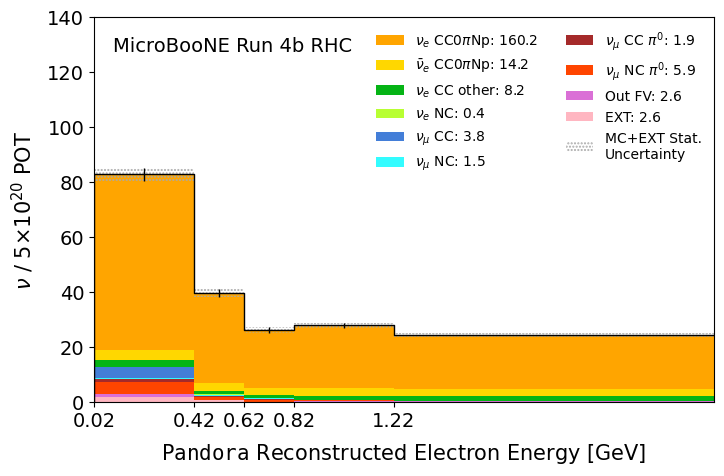

In [55]:
variable = "pandora_shr_energy_cali"
bins = [0.02, 0.42, 0.62, 0.82, 1.22, 7.00]
xlow = bins[0]
xhigh = 2.5 # Previously 3, wants to be changed to 2.5! 
x_label = "Electron Energy [GeV]"
x_ticks = [0.02, 0.42, 0.62, 0.82, 1.22]

x = plot_mc('pandora_shr_energy_cali', bins, xlow, xhigh, pandora_final_query, 
            datasets_bdt_new, ISRUN3, x_label=r"$\mathtt{Pandora}$ Reconstructed Electron Energy [GeV]", 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=True, xmax=xhigh, ymax=140, x_ticks=x_ticks)

### `WireCell`

total selected = 168.628943726673
saving to: /Users/abarnard/phd/ccnp/uBNuMI_CC1eNp/plots/rhc/


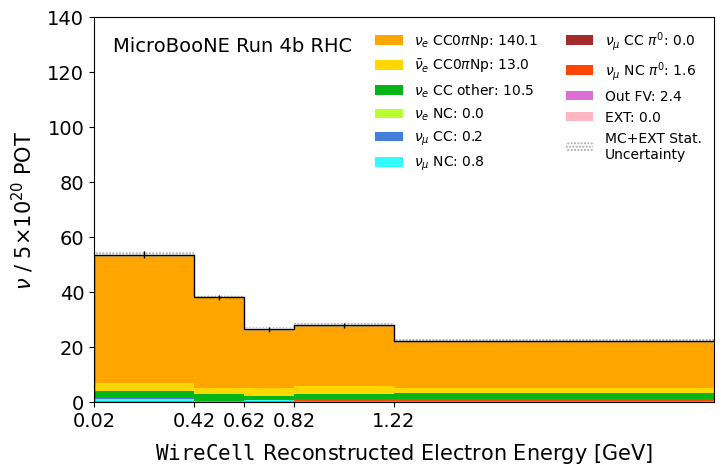

In [56]:
variable = "wc3_reco_showerKE"
bins = [0.02, 0.42, 0.62, 0.82, 1.22, 7.00]
xlow = bins[0]
xhigh = 2.5 # Previously 3, wants to be changed to 2.5! 
x_label = "Electron Energy [GeV]"
x_ticks = [0.02, 0.42, 0.62, 0.82, 1.22]

x = plot_mc('wc3_reco_showerKE', bins, xlow, xhigh, WC_FINAL_QUERY, 
            datasets_bdt_new, ISRUN3, x_label=r"$\mathtt{WireCell}$ Reconstructed Electron Energy [GeV]", 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=True, xmax=xhigh, ymax=140, x_ticks=x_ticks)

### Unified

In [57]:
variable = "pandora_shr_energy_cali"
bins = [0.02, 0.42, 0.62, 0.82, 1.22, 7.00]
xlow = bins[0]
xhigh = 2.5 # Previously 3, wants to be changed to 2.5! 
x_label = "Electron Energy [GeV]"
x_ticks = [0.02, 0.42, 0.62, 0.82, 1.22]

# THIS IS ALREADY CUT ON!

x = plot_mc('pandora_shr_energy_cali', bins, xlow, xhigh, "", 
            datasets_union, ISRUN3, x_label=r"$\mathtt{Pandora}$ Reconstructed Electron Energy [GeV]", 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=True, xmax=xhigh, ymax=140, x_ticks=x_ticks)

KeyboardInterrupt: 

# Plotting Selection Variables

In [ ]:
# NO EXT - FOR A MORE DIRECT COMPARISON

from backend_functions.selection_functions import plot_mc_no_ext
from selection_functions import plot_mc
import matplotlib.pyplot as plt

# Get the plot data and extract the total selected events
bins = [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40]
xlow = bins[0]
xhigh = bins[-1]

x = plot_mc('shrmoliereavg', bins, xlow, xhigh, BDT_LOOSE_CUTS, 
            datasets, ISRUN3, x_label="Average Shower Molière Angle [deg]", 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=False, xmax=xhigh, ymax=195)

In [ ]:
# NO EXT - FOR A MORE DIRECT COMPARISON
# Get the plot data and extract the total selected events
bins = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0]
xlow = bins[0]
xhigh = bins[-1]

x = plot_mc_no_ext('shr_tkfit_dedx_Y', bins, xlow, xhigh, PRE_QUERY, 
            datasets, ISRUN3, x_label=r"$\mathrm{d}\mathit{E}/\mathrm{d}\mathit{x}$ on the Collection Plane [MeV/cm]", 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=False, xmax=xhigh, ymax=140)

In [ ]:
# NO EXT - FOR A MORE DIRECT COMPARISON
# Get the plot data and extract the total selected events
bins = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
xlow = bins[0]
xhigh = bins[-1]

x = plot_mc_no_ext('tksh_distance', bins, xlow, xhigh, PRE_QUERY, 
            datasets, ISRUN3, x_label="3D Distance Between Track & Shower [cm]", 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=False, xmax=xhigh, ymax=150)

In [ ]:
# PROTON MULTIPLICITY 
x = plot_mc('trkpid', bins, xlow, xhigh, BDT_PRE_QUERY, 
            datasets_bdt_new, ISRUN3, x_label="Track PID Score", 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=True, xmax=xhigh, ymax=850, x_ticks=x_ticks)

In [ ]:
from selection_functions import draw_root_like

# Replace inf/-inf with NaN, then drop NaNs for plotting
wc2_nue_score_clean = nue['wc2_nue_score'].replace([np.inf, -np.inf], np.nan).dropna()

draw_root_like(wc2_nue_score_clean, bins='auto', xlabel='shr_score', title='WireCell Nue Score', logy=False, max_value=60000)

In [ ]:
# Preselection
WC_PRE_QUERYZ = reco_in_fv_query # Reconstructed vertex must be within Pandora-value FV
WC_PRE_QUERYZ += ' and wc2_numu_cc_flag >= 0' # Valid numu CC flag
WC_PRE_QUERYZ += ' and wc1_match_isFC == 1' # Event must be fully contained

# Signal definition constraints - protons, electrons, and pi0s have energy thresholds added 
WC_PRE_QUERYZ += ' and reco_electron == 1' # One reconstructed electron
WC_PRE_QUERYZ += ' and reco_proton > 0' # At least one reconstructed proton
WC_PRE_QUERYZ += ' and reco_mu == 0' # No reconstructed muons
WC_PRE_QUERYZ += ' and reco_pi0 == 0' # No reconstructed pi0s

bins = [-17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
xlow = bins[0]
xhigh = bins[-1]

x = plot_mc(
    'wc2_nue_score', bins, xlow, xhigh, WC_PRE_QUERYZ,
    datasets_bdt_new, ISRUN3,
    x_label = r'$\mathtt{WireCell}$ $\mathrm{\nu_e}$ Score',
    norm='data',
    y_label=r'$\nu / 5\times10^{20}\ \text{POT}$',
    sys=None, plot_bkgd=False, save=True,
    xmax=xhigh, ymax=95
)

# BDT Selection (Pandora)

In [ ]:
# load bdt model 
split = 1
bdt_model = xgb.Booster({'nthread': 4})
bdt_model.load_model(parameters(ISRUN3)['bdt_model'])
    
datasets_bdt = {}

for i in range(len(datasets)): 

    df = list(datasets.values())[i].copy()
    df = df.query(BDT_LOOSE_CUTS)

    # clean datasets 
    for column in training_parameters:
        df.loc[(df[column] < -1.0e37) | (df[column] > 1.0e37), column] = np.nan

    # create testing dmatrix 
    df_test = xgb.DMatrix(data=df[training_parameters])

    # apply the bdt selection
    preds = bdt_model.predict(df_test)

    # add columns for plotting 
    df['BDT_score'] = preds

    datasets_bdt[list(datasets.keys())[i]] = df
    

In [ ]:
bdt_score_cut = parameters(ISRUN3)['bdt_score_cut']
    
print("BDT SCORE THRESHOLD = "+str(bdt_score_cut))

selected_query = BDT_LOOSE_CUTS + ' and BDT_score>'+str(bdt_score_cut)
selected_signal_query = selected_query + ' and is_signal==True'


In [ ]:
datasets_bdt['outfv'].nu_e

In [ ]:
print("GENERATED SIGNAL (DATA NORMALIZED) = "+str(sum(top.generated_signal(ISRUN3, 'nu_e', [0,20], 0, 20)[0]))) # Is this weight the default?

In [ ]:
# BDT score output 

x = plot_mc('BDT_score', [round(x*0.1, 2) for x in range(11)], 0, 1, BDT_LOOSE_CUTS, 
            datasets_bdt, ISRUN3, x_label="BDT Score", # 'BDT Probability Score'
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=True, xmax=0.8, ymax=170)#, ymax=100)

In [ ]:
x = plot_mc('BDT_score', [round(x*0.025, 3) for x in range(0,41)], 0.075, 0.8, BDT_LOOSE_CUTS, 
            datasets_bdt, ISRUN3, x_label="BDT Score", 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=True, xmax=0.8, ymax=55)#, ymax=100)

In [ ]:
bins = [0.02, 0.42, 0.62, 0.82, 1.22, 7.00]
xlow = bins[0]
xhigh = 2.5 # Previously 3, wants to be changed to 2.5! 
    
x_label = "Electron Energy [GeV]"
x_ticks = [0.02, 0.42, 0.62, 0.82, 1.22]

# Create the BDT selection query with score > 0.55
bdt_query = BDT_LOOSE_CUTS + ' and BDT_score > 0.55'

x = plot_mc('shr_energy_cali', bins, xlow, xhigh, bdt_query, 
            datasets_bdt, ISRUN3, x_label=x_label, 
            norm='data', y_label='$\\nu$ / 5$\\times10^{20}$ POT', sys=None, plot_bkgd=False, save=True, xmax=xhigh, ymax=100, x_ticks=x_ticks)

### Performance 

#### SHAP Analysis

In [ ]:
# Simple SHAP setup
import shap
import xgboost as xgb

# Load training data using the function from selection_functions
training_data_file = 'BDT_training_data/training_data_run4brhc_scaled_noext_noshrscore.pkl'
X_train, y_train, X_test, y_test, feature_names, data_package = load_training_data_for_shap(training_data_file)

# Load model (use existing bdt_model from session)
model = bdt_model

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

print("✅ SHAP setup complete!")
print(f"Training samples: {len(X_test)}")
print(f"Features: {len(feature_names)}")
print("Ready for SHAP analysis!")

In [ ]:
import numpy as np
import pandas as pd

print("🧹 Cleaning X_test for SHAP analysis...")

# Step 1: Replace infinite values (±inf) with NaN
X_test_clean = X_test.replace([np.inf, -np.inf], np.nan)

# Step 2: Detect “float overflow” placeholder values (~3.4e38)
# (These often appear when float32 values overflow or are used to mark missing data)
float32_max = np.finfo(np.float32).max
mask_overflow = (X_test_clean.abs() >= float32_max * 0.9)  # near the limit
overflow_count = mask_overflow.sum().sum()
if overflow_count > 0:
    print(f"⚠️ Found {overflow_count} extreme float values near ±3.4e38. Replacing with NaN...")
    X_test_clean = X_test_clean.mask(mask_overflow, np.nan)

# Step 3: Handle NaNs — choose fill strategy
# Option A: fill with 0 (neutral baseline)
X_test_clean = X_test_clean.fillna(0)
# Option B (optional): fill with column means instead
# X_test_clean = X_test_clean.fillna(X_test_clean.mean())

# Step 4: Clip any remaining extreme magnitudes (optional safeguard)
X_test_clean = X_test_clean.clip(-1e10, 1e10)

# Step 5: Confirm everything is finite
if not np.isfinite(X_test_clean.to_numpy()).all():
    print("⚠️ Non-finite values remain! Double-check preprocessing.")
else:
    print("✅ Data cleaned: all values finite and within safe range.")

# (Optional) preview a few columns with formerly huge values
cols_with_large = (mask_overflow.sum() > 0)
if cols_with_large.any():
    print("Columns affected by cleaning:")
    print(X_test.columns[cols_with_large].tolist())
# Step 6: Use the cleaned dataset going forward
X_test = X_test_clean

Making the SHAP beeswarm plot using shap.plots.beeswarm. Here, I'm using the test dataset. 

In [ ]:
# SHAP Beeswarm Plot with Direction Labels
import shap
import matplotlib.pyplot as plt
import numpy as np

try:
    # Check if we have everything needed from the previous cell
    if 'explainer' in locals() and explainer is not None and 'X_test' in locals() and X_test is not None:
        print("Generating SHAP beeswarm plot...")
        
        # For computational efficiency, use a sample of training data
        sample_size = min(277005, len(X_test))
        X_sample = X_test.sample(n=sample_size, random_state=42)
        
        print(f"Computing SHAP values for {sample_size} samples...")
        shap_values = explainer.shap_values(X_sample)
        
        # Create the beeswarm plot
        plt.figure(figsize=(12, 8))
        shap.plots.beeswarm(
            shap.Explanation(
                values=shap_values if not isinstance(shap_values, list) else shap_values[0],
                data=X_sample.values,
                feature_names=feature_names
            ),
            max_display=15,
            show=False
        )
        
        # --- Modify tick label font ---
        ax = plt.gca()
        for label in ax.get_yticklabels():
            label.set_fontfamily('monospace')
            label.set_fontsize(11)
        
        # --- Add custom axis and colorbar labels ---
        plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=12)
        fig = plt.gcf()
        axes = fig.get_axes()
        if len(axes) > 1:
            cbar = axes[-1]
            cbar.set_ylabel("Feature Value", fontsize=12)
        
        # --- Title ---
        plt.title('SHAP Beeswarm Plot - Run 4b RHC BDT (Scaled, No Ext)', fontsize=12)
        
        # --- Add custom "direction" text labels ---
        # Get current axis limits so we position the text correctly
        x_min, x_max = ax.get_xlim()
        y_min, y_max = ax.get_ylim()
        
        # Add text slightly below the x-axis limits
        y_pos = y_min + 0.5  # adjust if text overlaps or is too far
        
        ax.text(x_min, y_pos, "← Away from Signal", fontsize=11, ha='left', va='top', color='dimgray')
        ax.text(x_max, y_pos, "Towards Signal →", fontsize=11, ha='right', va='top', color='dimgray')
        
        # --- Layout and show ---
        plt.tight_layout()
        plt.savefig('shap_beeswarm_run4brhc_scaled_noext_labels.pdf', bbox_inches='tight')
        plt.show()
        
        print("✅ SHAP beeswarm plot generated successfully!")
        print("This plot shows:")
        print("- Features ordered by importance (top to bottom)")
        print("- Each dot represents one sample")
        print("- X-axis shows SHAP value (impact on model output)")
        print("- Color indicates feature value (red=high, blue=low)")
        print("- Direction labels indicate movement away/towards the signal")
        
    else:
        print("❌ Missing required data for beeswarm plot")
        
except Exception as e:
    print(f"Error generating beeswarm plot: {e}")
    import traceback
    traceback.print_exc()

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type='violin')

In [ ]:
int_labels = {
    '0': 'CCQE', 
    '1': 'CC Res', 
    '2': 'CC DIS', 
    '3': 'CC Coh', 
    '10': 'CC MEC' 
}

fig = plt.figure(figsize=(8, 5))

xvar = 'nu_e'

ccqe = datasets_bdt['infv'].query(selected_signal_query+' and interaction==0')
ccres = datasets_bdt['infv'].query(selected_signal_query+' and interaction==1')
ccdis = datasets_bdt['infv'].query(selected_signal_query+' and interaction==2')
cccoh = datasets_bdt['infv'].query(selected_signal_query+' and interaction==3')
ccmec = datasets_bdt['infv'].query(selected_signal_query+' and interaction==10')

int_weights = [ccqe['totweight_data'], 
                 ccres['totweight_data'], 
                 ccdis['totweight_data'], 
                 cccoh['totweight_data'], 
                 ccmec['totweight_data']]

int_counts = []
for l in int_weights: 
    int_counts.append( np.nansum(l) )
    
tot_count = sum(int_counts)
int_counts = [str(round((x/tot_count)*100, 1)) for x in int_counts]

# signal broken down by interactions after the selection 
n, b, p = plt.hist([ccqe[xvar], ccres[xvar], ccdis[xvar], cccoh[xvar], ccmec[xvar]],
          [x*0.25 for x in range(25)], 
          weights=int_weights,
          label=[int_labels['0']+' ('+int_counts[0]+'%)', 
                 int_labels['1']+' ('+int_counts[1]+'%)', 
                 int_labels['2']+' ('+int_counts[2]+'%)', 
                 int_labels['3']+' ('+int_counts[3]+'%)', 
                 int_labels['10']+' ('+int_counts[4]+'%)'],
          color=[ 'blueviolet','cornflowerblue','navy',  'orangered', 'deeppink'], # Change colours here!
          stacked=True)

bincenters = 0.5*(b[1:]+b[:-1])

y_err = mc_error(xvar, b, b[0], b[-1], [datasets_bdt['infv'].query(selected_signal_query)])
#y_err = [x*y for x, y in zip(n[-1], signal_percent_err)]

plt.hist(bincenters, b, color='black', linewidth=0.75, weights=n[-1], histtype='step')
plt.errorbar(bincenters, n[-1], yerr=y_err,
             color='black', linewidth=.75, fmt='none')#, alpha=.7)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.xlabel("True Neutrino Energy [GeV]", fontsize=15)
plt.ylabel('$\\nu$ / $2\\times10^{20}$ POT', fontsize=15)
#plt.title('FHC RUN 1 Selected Event Rate', fontsize=16)

plt.legend(frameon=False, fontsize=14)

plt.xlim(0, 6)

#plt.savefig("/uboone/app/users/abarnard/katrina_analysis/code/uBNuMI_CC1eNp/FHCSelectedInteractions.pdf", transparent=True, bbox_inches='tight') 

#plt.savefig(parameters(ISRUN3)['plots_path']+"FHCSelectedInteractions.pdf", transparent=True, bbox_inches='tight') 

plt.show()

In [ ]:
q = BDT_LOOSE_CUTS+' and BDT_score>'+str(bdt_score_cut)
q

In [ ]:
useBDT = True

if useBDT: 
    datasets_dict = datasets_bdt
else: 
    datasets_dict = datasets

In [ ]:

tot_sig_sel = np.nansum(datasets_dict['infv'].query(q+' and is_signal==True').totweight_data)
tot_sel = np.nansum(datasets_dict['infv'].query(q).totweight_data) + np.nansum(datasets_dict['outfv'].query(q).totweight_data) + np.nansum(datasets_dict['ext'].query(q).pot_scale)
tot_sig = sum(generated_signal(ISRUN3, 'nu_e', [0,100], 0, 100)[0])

print("Efficiency = ", tot_sig_sel/tot_sig)
print("Purity = ", tot_sig_sel/tot_sel)


In [ ]:
datasets_dict['infv'].query(q+' and is_signal==True')["shr_energy_cali"].min()

In [ ]:
datasets_dict['data'].query(q)["shr_energy_cali"].min()

## BDT Training

In [ ]:
TRAIN = True
save_bdt = True

In [ ]:
# ========================================
# TOGGLE: Set to False to exclude EXT from BDT training
# ========================================
USE_EXT_IN_BDT = False

# When False: BDT trains on MC signal vs background only (no beam-off EXT data)
# When True: BDT trains with EXT included as additional background (original behavior)

In [ ]:
# Conditionally build datasets dictionary based on USE_EXT_IN_BDT flag
# Override previous 'datasets' definition for BDT training
if USE_EXT_IN_BDT:
    datasets = {
        "infv": infv, 
        "outfv": outfv,
        "ext": ext 
    }
    print("Datasets created WITH EXT for BDT training")
else:
    datasets = {
        "infv": infv, 
        "outfv": outfv
    }
    print("Datasets created WITHOUT EXT for BDT training")

In [ ]:
# Verify the datasets dictionary structure
print("Available datasets:", list(datasets.keys()))
print("USE_EXT_IN_BDT is set to:", USE_EXT_IN_BDT)
print("\nDataset sizes:")
for key, df in datasets.items():
    print(f"  {key}: {len(df):,} events")

In [ ]:

# TRAIN ON A SUBSET OF THE DISTRIBUTION
train_query = BDT_LOOSE_CUTS + ' and -0.9<tksh_angle<0.9' #and shr_energy_tot_cali>0.07'
test_query = BDT_LOOSE_CUTS


In [ ]:
# subset distributions 

x = plot_mc_no_ext('tksh_angle', [-1, -.9, -.8, -.7, -.6, -.5, -.4, -.3, -.2, -.1] + list(round(x*0.1,2) for x in range(11)), 
        -1, 1, test_query, datasets, ISRUN3, norm='data')
        #save=False, save_label='RHCRUN3_loosecuts_mconly', log=False, x_label='$cos(\\theta_{ep})$',
        #text='FHC RUN 1', xtext=0.75, ytext=70)

x = plot_mc_no_ext('shr_energy_tot_cali', list(x*0.01 for x in range(21)), 
        0, 0.2, test_query, datasets, ISRUN3, norm='data', ymax=65)
        #save=False, save_label='RHCRUN3_loosecuts_mconly', log=False, x_label='Total Calibrated Shower Energy [GeV]', 
        #text='FHC RUN 1', xtext=0.19, ytext=35)


In [ ]:
# df_pre = addRelevantColumns(datasets) 
df_pre = addRelevantColumns_flexible(datasets, USE_EXT_IN_BDT=USE_EXT_IN_BDT)

In [ ]:
total_signal_generated_intrinsic = sum(top.generated_signal(ISRUN3, 'nu_e', [0,100], 0, 100, weight='totweight_intrinsic')[0])
print(total_signal_generated_intrinsic)

In [ ]:
total_signal_generated = sum(generated_signal(ISRUN3, 'nu_e', [0,100], 0, 100)[0])
print(total_signal_generated)

#### Pre BDT performance as a function of test sample size 

In [ ]:
# efficiency of total sample 
e_total = sum(df_pre.query(test_query+ ' and is_signal==True')['weight']) / total_signal_generated 

# efficiency error - binomial (use the intrinsic event count)
e_total_err = np.sqrt(e_total * (1-e_total) / total_signal_generated_intrinsic) * 100 

# purity of total sample 
p_total = sum(df_pre.query(test_query+ ' and is_signal==True')['weight']) / sum(df_pre.query(test_query)['weight'])

# purity error - poissonian 
p_total_err = (p_total * np.sqrt( sum(df_pre.query(test_query+' and is_signal==True').weight**2)/(sum(df_pre.query(test_query+' and is_signal==True').weight)**2) + sum(df_pre.query(test_query).weight**2)/(sum(df_pre.query(test_query).weight)**2) )) * 100

e_total = e_total*100
p_total = p_total*100


# store efficiency & purity values
e = []
e_err = []

p = []
p_err = []

xpoints = [round(i*0.05, 2) for i in range(20)]

for test_size in xpoints[1:]: 

    df_pre_train, df_pre_test = train_test_split(df_pre, test_size=test_size, 
                                             random_state=17, stratify=df_pre['is_signal'])
    
    total_signal_selected = sum(df_pre_test.query(test_query+ ' and is_signal==True')['weight'])
    total_selected = sum(df_pre_test.query(test_query)['weight'])
    
    eff = total_signal_selected / (total_signal_generated*test_size) 
    pur = total_signal_selected / total_selected
    
    e.append(eff*100)
    p.append(pur*100)
    
    e_err.append( np.sqrt( (eff*(1-eff)) / (total_signal_generated_intrinsic*test_size) ) * 100) # use the intrinsic event count
    p_err.append( (pur * np.sqrt( sum(df_pre_test.query(test_query+' and is_signal==True').weight**2)/sum(df_pre_test.query(test_query+' and is_signal==True').weight)**2 + sum(df_pre_test.query(test_query).weight**2)/sum(df_pre_test.query(test_query).weight)**2) )*100 ) 
                 

In [ ]:

plt.figure(figsize=(7.5, 5))

plt.errorbar(xpoints[1:], p, yerr=p_err, label="Purity (Test Sample)", color='firebrick', marker='.')
plt.axhline(y=p_total, label="Purity (Full)", color='firebrick', linewidth=1, linestyle="--")

plt.fill_between(xpoints, p_total-p_total_err, p_total+p_total_err, color='firebrick', alpha=0.1)


plt.ylim(40, 70)
plt.xlim(xpoints[0], xpoints[-1])
plt.grid(linestyle=':')
plt.legend(fontsize=13, ncol=2)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.xlabel('Test Sample Size (Relative to Full Sample)', fontsize=14)
plt.ylabel('Performance (%)', fontsize=14)

if ISRUN3: 
    plt.title('Run 4b RHC Pre-BDT Purity', fontsize=15)
#    plt.savefig(parameters(ISRUN3)['plots_path']+"RHCStratPerf_Purity.pdf", transparent=True, bbox_inches='tight') 
else: 
    plt.title('FHC Run 1 Pre-BDT Purity', fontsize=15)
#    plt.savefig(parameters(ISRUN3)['plots_path']+"FHCStratPerf_Purity.pdf", transparent=True, bbox_inches='tight') 


plt.show()



In [ ]:

plt.figure(figsize=(7.5, 5))

plt.errorbar(xpoints[1:], e, yerr=e_err, label="Efficiency (Test Sample)", color='seagreen', marker='.')
plt.axhline(y=e_total, label="Efficiency (Full)", color='seagreen', linewidth=1, linestyle="--")

plt.fill_between(xpoints, e_total-e_total_err, e_total+e_total_err, color='seagreen', alpha=0.1)


plt.ylim(30, 40)
plt.xlim(xpoints[0], xpoints[-1])
plt.grid(linestyle=':')
plt.legend(fontsize=13, ncol=2)

plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.xlabel('Test Sample Size (Relative to Full Sample)', fontsize=14)
plt.ylabel('Performance (%)', fontsize=14)

if ISRUN3: 
    plt.title('Run 4b RHC Pre-BDT Efficiency', fontsize=15)
    #plt.savefig(parameters(ISRUN3)['plots_path']+"RHCStratPerf_Efficiency.pdf", transparent=True, bbox_inches='tight') 
else: 
    plt.title('FHC Run 1 Pre-BDT Efficiency', fontsize=15)
    #plt.savefig(parameters(ISRUN3)['plots_path']+"FHCStratPerf_Efficiency.pdf", transparent=True, bbox_inches='tight') 

plt.show()

In [ ]:
# Calculate optimal test sample size based on convergence with full sample

# Convert to numpy arrays for easier calculation
e_array = np.array(e)
p_array = np.array(p)
e_err_array = np.array(e_err)
p_err_array = np.array(p_err)
xpoints_array = np.array(xpoints[1:])

# Find where efficiency converges (within uncertainty band of full sample)
# Check if test sample value is within the full sample uncertainty band
eff_converged = np.abs(e_array - e_total) <= e_total_err

# Find where purity converges
pur_converged = np.abs(p_array - p_total) <= p_total_err

# Find the first point where each metric converges
eff_convergence_idx = np.argmax(eff_converged) if np.any(eff_converged) else None
pur_convergence_idx = np.argmax(pur_converged) if np.any(pur_converged) else None

print("=" * 80)
print("CONVERGENCE ANALYSIS")
print("=" * 80)
print(f"\nFull Sample Efficiency: {e_total:.2f} ± {e_total_err:.2f}%")
print(f"Full Sample Purity: {p_total:.2f} ± {p_total_err:.2f}%")

if eff_convergence_idx is not None:
    eff_convergence_size = xpoints_array[eff_convergence_idx]
    print(f"\nEfficiency first converges at test size: {eff_convergence_size:.2f}")
    print(f"  Value at convergence: {e_array[eff_convergence_idx]:.2f} ± {e_err_array[eff_convergence_idx]:.2f}%")
    print(f"  Deviation from full: {abs(e_array[eff_convergence_idx] - e_total):.2f}%")
else:
    print("\nEfficiency does not converge within the tested range")

if pur_convergence_idx is not None:
    pur_convergence_size = xpoints_array[pur_convergence_idx]
    print(f"\nPurity first converges at test size: {pur_convergence_size:.2f}")
    print(f"  Value at convergence: {p_array[pur_convergence_idx]:.2f} ± {p_err_array[pur_convergence_idx]:.2f}%")
    print(f"  Deviation from full: {abs(p_array[pur_convergence_idx] - p_total):.2f}%")
else:
    print("\nPurity does not converge within the tested range")

# Find optimal test size (where BOTH metrics have converged)
both_converged = eff_converged & pur_converged
if np.any(both_converged):
    optimal_idx = np.argmax(both_converged)
    optimal_test_size = xpoints_array[optimal_idx]
    print(f"\n{'=' * 80}")
    print(f"OPTIMAL TEST SIZE (where both metrics converge): {optimal_test_size:.2f}")
    print(f"{'=' * 80}")
    print(f"  Efficiency: {e_array[optimal_idx]:.2f} ± {e_err_array[optimal_idx]:.2f}% (Full: {e_total:.2f}%)")
    print(f"  Purity: {p_array[optimal_idx]:.2f} ± {p_err_array[optimal_idx]:.2f}% (Full: {p_total:.2f}%)")
    print(f"  Efficiency deviation: {abs(e_array[optimal_idx] - e_total):.2f}%")
    print(f"  Purity deviation: {abs(p_array[optimal_idx] - p_total):.2f}%")
else:
    # If we want a more conservative approach, find where both metrics 
    # are within 2x their uncertainty
    print(f"\n{'=' * 80}")
    print("Neither metric converges within 1σ, checking alternative criteria...")
    print(f"{'=' * 80}")
    
    # Alternative: take the larger of the two convergence points
    if eff_convergence_idx is not None and pur_convergence_idx is not None:
        optimal_test_size = max(eff_convergence_size, pur_convergence_size)
        print(f"\nRecommended test size (max of individual convergence): {optimal_test_size:.2f}")
    elif eff_convergence_idx is not None:
        optimal_test_size = eff_convergence_size
        print(f"\nRecommended test size (efficiency only): {optimal_test_size:.2f}")
    elif pur_convergence_idx is not None:
        optimal_test_size = pur_convergence_size
        print(f"\nRecommended test size (purity only): {optimal_test_size:.2f}")
    else:
        # Use the point with minimum combined relative deviation
        rel_eff_dev = np.abs(e_array - e_total) / e_total_err
        rel_pur_dev = np.abs(p_array - p_total) / p_total_err
        combined_dev = np.sqrt(rel_eff_dev**2 + rel_pur_dev**2)
        optimal_idx = np.argmin(combined_dev)
        optimal_test_size = xpoints_array[optimal_idx]
        print(f"\nRecommended test size (minimum combined deviation): {optimal_test_size:.2f}")
        print(f"  Efficiency deviation: {rel_eff_dev[optimal_idx]:.2f}σ")
        print(f"  Purity deviation: {rel_pur_dev[optimal_idx]:.2f}σ")
        print(f"  Combined deviation: {combined_dev[optimal_idx]:.2f}σ")

print(f"\n{'=' * 80}\n")

In [ ]:
# Visualize convergence with shaded regions

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Efficiency plot
ax1.errorbar(xpoints_array, e_array, yerr=e_err_array, label="Efficiency (Test Sample)", 
             color='seagreen', marker='o', markersize=5, linewidth=1.5)
ax1.axhline(y=e_total, label="Efficiency (Full Sample)", color='seagreen', linewidth=2, linestyle="--")
ax1.fill_between(xpoints, e_total-e_total_err, e_total+e_total_err, 
                  color='seagreen', alpha=0.2, label='Full Sample ±1σ')

# Mark convergence region for efficiency
if eff_convergence_idx is not None:
    ax1.axvline(x=eff_convergence_size, color='seagreen', linestyle=':', 
                alpha=0.5, linewidth=2, label=f'Convergence @ {eff_convergence_size:.2f}')
    ax1.axvspan(eff_convergence_size, xpoints[-1], alpha=0.1, color='seagreen')

ax1.set_ylabel('Efficiency (%)', fontsize=14)
ax1.grid(linestyle=':', alpha=0.5)
ax1.legend(fontsize=11, loc='lower right')
ax1.set_ylim(30, 40)
ax1.tick_params(axis='both', labelsize=13)


# Purity plot
ax2.errorbar(xpoints_array, p_array, yerr=p_err_array, label="Purity (Test Sample)", 
             color='firebrick', marker='o', markersize=5, linewidth=1.5)
ax2.axhline(y=p_total, label="Purity (Full Sample)", color='firebrick', linewidth=2, linestyle="--")
ax2.fill_between(xpoints, p_total-p_total_err, p_total+p_total_err, 
                  color='firebrick', alpha=0.2, label='Full Sample ±1σ')

# Mark convergence region for purity
if pur_convergence_idx is not None:
    ax2.axvline(x=pur_convergence_size, color='firebrick', linestyle=':', 
                alpha=0.5, linewidth=2, label=f'Convergence @ {pur_convergence_size:.2f}')
    ax2.axvspan(pur_convergence_size, xpoints[-1], alpha=0.1, color='firebrick')

ax2.set_xlabel('Test Sample Size (Relative to Full Sample)', fontsize=14)
ax2.set_ylabel('Purity (%)', fontsize=14)
ax2.grid(linestyle=':', alpha=0.5)
ax2.legend(fontsize=10, loc='lower right')
ax2.set_ylim(40, 70)
ax2.set_xlim(xpoints[0], xpoints[-1])
ax2.tick_params(axis='both', labelsize=13)

# Add optimal test size marker if both converge
if np.any(both_converged):
    for ax in [ax1, ax2]:
        ax.axvline(x=optimal_test_size, color='black', linestyle='-', 
                   alpha=0.7, linewidth=2.5, label=f'Optimal @ {optimal_test_size:.2f}')
        # Update legend to include optimal line
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, fontsize=10, loc='lower right')

if ISRUN3:
    fig.suptitle('Run 4b RHC Pre-BDT Performance Convergence', fontsize=15, y=0.97)
else:
    fig.suptitle('FHC Run 1 Pre-BDT Performance Convergence', fontsize=15, y=0.995)

plt.tight_layout()

# plt.savefig("RHCStratPerf_Convergence_Scaled.pdf", transparent=True, bbox_inches='tight')

plt.show()

#### AUC & AUCPR Metrics

In [ ]:
final_test_size = 0.35

In [ ]:
import importlib
import backend_functions.selection_functions as selection_functions
importlib.reload(selection_functions)

In [ ]:
# Check the boosting rounds 

# Split arrays or matrices into random train and test subsets
df_pre_train, df_pre_test = selection_functions.train_test_split(df_pre, test_size=final_test_size, 
                                             random_state=17, stratify=df_pre['is_signal'])

selection_functions.bdt_metrics(df_pre_train, df_pre_test, train_query, test_query, 
            training_parameters, ISRUN3, save=True, verbose=False)

#### Create new BDT model 

In [ ]:
# pre-determined boosting round numbers
# Make sure to change this depending on performance above!

if not ISRUN3: # FHC
    lc_rounds = 200
    
else: # RHC
    lc_rounds = 500

#test train split 
split = final_test_size
print('split', split)


In [ ]:
import importlib
import backend_functions.selection_functions as selection_functions
importlib.reload(selection_functions)

In [ ]:
if TRAIN: 
    
    # BDT training - backend function cleans the dataset first 
    bdt_lc = selection_functions.main_BDT(datasets, train_query, test_query, lc_rounds, training_parameters, ISRUN3, test_size=split, USE_EXT_IN_BDT=USE_EXT_IN_BDT)

    results_df = bdt_lc['bdt_results_df']
    bdt_model = bdt_lc['bdt_model']
    train_df = bdt_lc['df_pre_train']
    test_df = bdt_lc['df_pre_test']
    
    # Split events into different categories based on is_mc flag and query
    # Reconstruct datasets_bdt from results_df
    datasets_bdt = {}
    
    # Split MC events into infv and outfv
    mc_results = results_df[results_df['is_mc'] == True].copy()
    datasets_bdt['infv'] = mc_results.query(in_fv_query) if 'in_fv_query' in dir() else mc_results[mc_results['is_signal'].notna()]
    datasets_bdt['outfv'] = mc_results.query(out_fv_query) if 'out_fv_query' in dir() else mc_results[mc_results['is_signal'] == False]
    
    # Add EXT if it was included in training
    if USE_EXT_IN_BDT and (results_df['is_mc'] == False).any():
        datasets_bdt['ext'] = results_df[results_df['is_mc'] == False].copy()

# note: all of the plots following be made with half the POT this way (test/train split)

In [ ]:
if save_bdt:
    import os
    os.makedirs('BDT_models', exist_ok=True)
    bdt_model.save_model('BDT_models/test_run4brhc_scaled_noext_noshrscore.model') 
    # Path to change which BDT you use is in the top.py script!
    print('saving BDT...')

### 💾 Accessing Training Data for Pre-trained BDT Models

Since BDT models don't store original training data, here are three approaches to access it later:

In [ ]:
# Save training data for later use (run this during/after BDT training)
if TRAIN and save_bdt:
    import os
    import pickle
    
    # Create directory for storing training data
    os.makedirs('BDT_training_data', exist_ok=True)
    
    # Save training data with metadata
    training_data_package = {
        'train_df': train_df,
        'test_df': test_df,
        'training_parameters': training_parameters,
        'train_query': train_query,
        'test_query': test_query,
        'split_ratio': split,
        'total_signal_generated': total_signal_generated,
        'total_signal_generated_intrinsic': total_signal_generated_intrinsic,
        'timestamp': pd.Timestamp.now().isoformat(),
        'model_path': 'BDT_models/test_run4brhc_scaled_noext_noshrscore.model'
    }
    
    # Save as pickle file
    with open('BDT_training_data/training_data_run4brhc_scaled_noext_noshrscore.pkl', 'wb') as f:
        pickle.dump(training_data_package, f)
    
    print("✅ Training data saved to 'BDT_training_data/training_data_run4brhc_scaled_noext_noshrscore.pkl'")
    print(f"   - Training events: {len(train_df):,}")
    print(f"   - Test events: {len(test_df):,}")
    print(f"   - Features: {len(training_parameters)}")
    print(f"   - Split ratio: {split}")
    
    # Also save just the essential training features as CSV for easy access
    train_features = train_df[training_parameters + ['is_signal', 'weight']].copy()
    train_features.to_csv('BDT_training_data/training_features_run4brhc_scaled_noext_noshrscore.csv', index=False)
    print("   - Training features also saved as CSV")
else:
    print("Skipping training data save (TRAIN=False or save_bdt=False)")

In [ ]:
import importlib
import backend_functions.selection_functions as selection_functions
importlib.reload(selection_functions)

In [ ]:
if TRAIN: 

    # performance of the linear selection for comparison
    gen_split = total_signal_generated*split
    eff_box = np.nansum(test_df.query(SEL_QUERY+' and is_signal==1').weight)/gen_split * 100

    tot_sel = np.nansum(test_df.query(SEL_QUERY)['weight']) 
    pur_box = np.nansum(test_df.query(SEL_QUERY+' and is_signal==1').weight) / tot_sel * 100

    results_box = [pur_box, eff_box]

    #  stat errors on the linear performance 
    e = eff_box/100

    eff_err = math.sqrt( (e*(1-e)) / total_signal_generated_intrinsic*split ) * 100
    pur_err = pur_box * np.sqrt( sum(test_df.query(SEL_QUERY+' and is_signal==1').weight**2)/sum(test_df.query(SEL_QUERY+' and is_signal==1').weight)**2 + sum(test_df.query(SEL_QUERY).weight**2)/sum(test_df.query(SEL_QUERY).weight)**2 )

    results_box_err = [pur_err, eff_err]

    # x values
    x = np.arange(0, 0.8, 0.025)

    # returns purity, purErr, eff, effErr
    perf_dict = selection_functions.bdt_pe(results_df, x, 
                  total_signal_generated, total_signal_generated_intrinsic, split)
    pur, pur_err, eff, eff_err = perf_dict['purity'], perf_dict['purErr'], perf_dict['eff'], perf_dict['effErr']
    
    selection_functions.bdt_box_plot([pur, pur_err, eff, eff_err], x, ISRUN3, save=False, results_box=results_box, results_box_err=results_box_err)

In [ ]:
bdt_svb_plot(results_df)

In [ ]:
## apply bdt model to the entire dataset

split = 1

datasets_bdt_full = {}

for i in range(len(datasets)): 

    df = list(datasets.values())[i].copy()
    df = df.query(BDT_LOOSE_CUTS)

    # clean datasets 
    for column in training_parameters:
        df.loc[(df[column] < -1.0e37) | (df[column] > 1.0e37), column] = np.nan

    # create testing dmatrix 
    df_test = xgb.DMatrix(data=df[training_parameters])

    # apply the bdt selection
    preds = bdt_model.predict(df_test)

    # add columns for plotting 
    df['BDT_score'] = preds

    datasets_bdt_full[list(datasets.keys())[i]] = df
  

In [ ]:
datasets_bdt_full.keys()

datasets_bdt_full['infv']['weight'] = list(datasets_bdt_full['infv'].totweight_data)
datasets_bdt_full['outfv']['weight'] = list(datasets_bdt_full['outfv'].totweight_data)

if USE_EXT_IN_BDT:
    datasets_bdt_full['ext']['weight'] = list(datasets_bdt_full['ext'].pot_scale)

In [ ]:
if USE_EXT_IN_BDT:
    datasets_bdt_full['tot_sim'] = pd.concat([datasets_bdt_full['infv'], datasets_bdt_full['outfv'], datasets_bdt_full['ext']])

else:
    datasets_bdt_full['tot_sim'] = pd.concat([datasets_bdt_full['infv'], datasets_bdt_full['outfv']])

#### Cross validation 

In [ ]:
from sklearn.model_selection import RepeatedStratifiedKFold

In [ ]:

splits = 2
repeats = 20
cv = RepeatedStratifiedKFold(n_splits=splits, n_repeats=repeats, random_state=36851234)

if ISRUN3: 
    bdt_score_arr = np.arange(0, 0.75, 0.025)
    
else: 
    bdt_score_arr = np.arange(0, 0.8, 0.025)



In [ ]:
# Use the flexible function for cross-validation
df_crossval = selection_functions.addRelevantColumns_flexible(datasets, USE_EXT_IN_BDT=USE_EXT_IN_BDT)

scale_weight = len(df_crossval.query(train_query + ' and is_signal == False')) / len(df_crossval.query(train_query + ' and is_signal == True'))
print("scale pos weight (ratio of negative to positive) = "+str(scale_weight))

In [ ]:
len(df_crossval.query(train_query + ' and is_signal == False'))

In [ ]:
#model params
params = {
        'objective': 'binary:logistic',
        'booster': 'gbtree',
        'eta': 0.02,
        'tree_method': 'exact',
        'max_depth': 3,
        'subsample': 0.8,
        'colsample_bytree': 1,
        'silent': 1,
        'min_child_weight': 1,
        'seed': 2002,
        'gamma': 1,
        'max_delta_step': 0,
        'scale_pos_weight': scale_weight,
        'eval_metric': ['error', 'auc', 'aucpr']
}

In [ ]:
final_purity = []
final_efficiency=[]

fp_err = []
fe_err = []

box_pur = []
box_eff = []

boxp_err = []
boxe_err = []

print('Note: must use 50/50 split for the cv.split function to work!')

for train_index, test_index in cv.split(df_crossval, df_crossval['is_signal']):
    
    train, test = df_crossval.iloc[train_index], df_crossval.iloc[test_index]    
    
    bdt_cv_lc = selection_functions.bdt_raw_results(train, test, train_query, test_query, training_parameters, params, lc_rounds)
    
    # saves purity, efficiency and respective errors on current test sample for loose cuts BDT
    perf = selection_functions.bdt_pe(bdt_cv_lc[0], bdt_score_arr, total_signal_generated, total_signal_generated_intrinsic, 0.5)
    pur, pur_err, eff, eff_err = perf['purity'], perf['purErr'], perf['eff'], perf['effErr']
    
    final_purity.append(pur)
    final_efficiency.append(eff)
    
    fp_err.append(pur_err)
    fe_err.append(eff_err)

    # LINEAR SELECTION PERFORMANCE 
    
    sig_sel = sum(test.query(SEL_QUERY+' and is_signal==1').weight)
    tot_sel = sum(test.query(SEL_QUERY).weight)
    
    tot_sig = total_signal_generated*0.5
    tot_sig_intrinsic = total_signal_generated_intrinsic*0.5
    
    p = sig_sel / tot_sel
    e = sig_sel / tot_sig
    
    box_pur.append(p * 100)
    box_eff.append(e * 100)
        
    boxp_err.append( p * np.sqrt( sum(test.query(SEL_QUERY+' and is_signal==True').weight**2)/sum(test.query(SEL_QUERY+' and is_signal==True').weight)**2 + sum(test.query(SEL_QUERY).weight**2)/sum(test.query(SEL_QUERY).weight)**2 ) * 100)
    boxe_err.append(math.sqrt( (e * (1-e)) / tot_sig_intrinsic) * 100)

In [ ]:
# averages results column-wise, which is equivalent to averaging results over the same BDT_score cut

results_bdt = [np.mean(final_purity, axis=0), np.mean(fp_err, axis=0), 
               np.mean(final_efficiency, axis=0), np.mean(fe_err, axis=0)]

# linear box cut selection is a normal average over each distinct test sample
results_box = [np.mean(box_pur), np.mean(box_eff)]
results_box_err = [np.mean(boxp_err), np.mean(boxe_err)]

In [ ]:
for i in range(len(bdt_score_arr)): 
    if bdt_score_arr[i]>=0.45: 
        print("BDT score > "+str(round(bdt_score_arr[i], 3)))
        print("efficiency = "+str(round(results_bdt[2][i], 1)))
        print("purity = "+str(round(results_bdt[0][i], 1)))

In [ ]:
if ISRUN3: 
    title = "Run 4b RHC Cross Validation"
    save_label = "RUN4BRHC_crossvalidation_noshrscore"
else: 
    title = "FHC Run 1 Cross Validation"
    save_label = "FHCRUN1_crossvalidation"

In [ ]:
import importlib
import backend_functions.selection_functions as selection_functions
importlib.reload(selection_functions)

In [ ]:
print("Available variables:")
print("selection_variables:", selection_variables)
print("training_parameters:", training_parameters)

In [ ]:
bdt_box_plot(results_bdt, bdt_score_arr, ISRUN3, results_box=results_box, results_box_err=results_box_err, 
           save=False, save_label=save_label, title=title) 

# MC event selection (for making event displays)

## Extract selected events from intrinsic file

In [ ]:
# Filter signal events in the intrinsic file and apply preselection cuts

# Check if nue dataframe exists
if 'nue' in locals() and isinstance(nue, pd.DataFrame):
    print(f"Total events in nue file: {len(nue):,}")
    
    print(f"\nPreselection cuts:")
    print(f"  {BDT_PRE_QUERY}")

    # Number of events passing signal definition
    nue_passing_signal_def = nue.query('is_signal == True')

    # Number of events passing preselection AND signal definition
    nue_preselected = nue_passing_signal_def.query(BDT_PRE_QUERY)

    print(f"\nEvents passing signal definition: {len(nue_passing_signal_def):,}")
    print(f"This is {100*len(nue_passing_signal_def)/len(nue):.2f}% of total nue events")

    print(f"\nEvents passing preselection AND signal definition: {len(nue_preselected):,}")
    print(f"This is {100*len(nue_preselected)/len(nue):.2f}% of total nue events")
    print(f"This is {100*len(nue_preselected)/len(nue_passing_signal_def):.2f}% of passing signal definition events")
    
else:
    print("Error: nue dataframe not found. Please run earlier cells to load the intrinsic file.")

### Get the run, subrun, and event numbers of selected events

In [ ]:
# Extract and display run, subrun, event numbers of selected events

if len(nue_preselected) > 0:
    # Extract the run, subrun, and event numbers
    event_info = nue_preselected[['run', 'sub', 'evt']].copy()

    # Convert to integers for cleaner display
    event_info['run'] = event_info['run'].astype(int)
    event_info['sub'] = event_info['sub'].astype(int)
    event_info['evt'] = event_info['evt'].astype(int)
    
    # Sort by run, subrun, then event
    event_info = event_info.sort_values(['run', 'sub', 'evt']).reset_index(drop=True)
    
    # Display the table
    print(f"\n{'='*60}")
    print(f"Selected Signal Events from Intrinsic File")
    print(f"(Passing signal definition and preselection cuts)")
    print(f"Total: {len(event_info)} events")
    print(f"{'='*60}\n")
    
    # Display the full table
    pd.set_option('display.max_rows', None)  # Show all rows
    pd.set_option('display.width', None)     # Don't wrap lines
    print(event_info.to_string(index=True))
    
    print(f"\n{'='*60}")
    print(f"Total selected events: {len(event_info)}")
    print(f"{'='*60}")
    
else:
    print("No events passed the selection criteria.")

### Display the MC particle information for the selected events

In [ ]:
# Display MC particle information for each selected event

if len(nue_preselected) > 0:
    # PDG code to particle name mapping
    pdg_names = {
        11:   'e-',      
        211:  'π+', 
        -211: 'π-',
        2112: 'n',
        2212: 'p',
        321:  'K+',     
        3122: 'Λ0',      
    }
    
    print(f"\n{'='*80}")
    print(f"MC Particle Information for Selected Events")
    print(f"{'='*80}\n")
    
    for idx, row in nue_preselected.iterrows():
        run = int(row['run'])
        sub = int(row['sub'])
        evt = int(row['evt'])
        
        print(f"Run: {run}, Subrun: {sub}, Event: {evt}   ({run} {sub} {evt})")
        print("-" * 80)
        
        # Get MC particle PDG codes for this event
        if 'mc_pdg' in row and isinstance(row['mc_pdg'], (list, np.ndarray)):
            mc_pdg_list = row['mc_pdg']
            
            # Count total particles
            total_particles = len(mc_pdg_list)
            print(f"  Total MC particles: {total_particles}")
            
            # Count each particle type
            from collections import Counter
            pdg_counts = Counter(mc_pdg_list)
            
            # Sort by PDG code
            print(f"  Particle breakdown:")
            for pdg_code in sorted(pdg_counts.keys()):
                count = pdg_counts[pdg_code]
                particle_name = pdg_names.get(pdg_code, f'PDG:{pdg_code}')
                print(f"    {particle_name:8s} (PDG {pdg_code:6d}): {count:3d}")
            
            # Print electron energies
            elec_e = row.get('elec_e', None)
            if elec_e is not None and not (isinstance(elec_e, float) and pd.isna(elec_e)):
                try:
                    e_gev = float(elec_e)
                    e_mev = e_gev * 1000  # convert to MeV
                    print(f"  Electron energy: {e_mev:.2f} MeV ({e_gev:.2f} GeV)")
                except Exception:
                    print(f"  Electron energy (non-numeric): {repr(elec_e)}")
            else:
                print("  No electron energy available")
        else:
            print("  No MC particle information available")
        
        print()
    
    print(f"{'='*80}")
    
else:
    print("No selected events to display MC particle information.")

### Events with lowest and highest electron energies

In [ ]:
# Find events with lowest and highest electron energies

# Ensure 'elec_e' column exists and has valid numeric values
if 'elec_e' in nue_preselected.columns:
    # Convert to numeric (ignore errors like None or strings)
    elec_series = pd.to_numeric(nue_preselected['elec_e'], errors='coerce')

    # Drop NaN values
    valid_elec = nue_preselected.loc[~elec_series.isna()].copy()
    valid_elec['elec_e'] = elec_series.loc[~elec_series.isna()]

    if len(valid_elec) > 0:
        # Get lowest and highest energy events
        min_idx = valid_elec['elec_e'].idxmin()
        max_idx = valid_elec['elec_e'].idxmax()

        min_row = valid_elec.loc[min_idx]
        max_row = valid_elec.loc[max_idx]

        print("\n" + "="*80)
        print("Events with Lowest and Highest Electron Energies")
        print("="*80)

        print(f"\nLowest electron energy event:")
        print(f"  Run: {int(min_row['run'])}, Subrun: {int(min_row['sub'])}, Event: {int(min_row['evt'])}   "
            f"({int(min_row['run'])} {int(min_row['sub'])} {int(min_row['evt'])})")
        print(f"  Electron energy: {min_row['elec_e']*1000:.2f} MeV ({min_row['elec_e']:.2f} GeV)")

        print(f"\nHighest electron energy event:")
        print(f"  Run: {int(max_row['run'])}, Subrun: {int(max_row['sub'])}, Event: {int(max_row['evt'])}   "
            f"({int(max_row['run'])} {int(max_row['sub'])} {int(max_row['evt'])})")
        print(f"  Electron energy: {max_row['elec_e']*1000:.2f} MeV ({max_row['elec_e']:.2f} GeV)")

        print("\n" + "="*80)
    else:
        print("No valid electron energies found in selected_events.")
else:
    print("No 'elec_e' column found in selected_events.")

In [ ]:
# Let's create a controlled test to demonstrate the pandas query inconsistency
import pandas as pd
import numpy as np

print("=== CONTROLLED TEST OF PANDAS QUERY BEHAVIOR ===")

# Create a simple test DataFrame with NaN values
test_df = pd.DataFrame({
    'value': [5.0, 10.0, 20.0, np.nan, 3.0, 25.0, np.nan],
    'id': [1, 2, 3, 4, 5, 6, 7]
})

print("Original test DataFrame:")
print(test_df)
print(f"Length: {len(test_df)}")

# Test 1: Apply query to original DataFrame
print("\n=== Test 1: Direct query on original DataFrame ===")
queried_df = test_df.query("value < 15")
print(f"After query 'value < 15': {len(queried_df)} rows")
print(queried_df)

# Test 2: Same approach as datasets_bdt - filter then clean
print("\n=== Test 2: Filter first, then clean (datasets_bdt approach) ===")
# Step 1: Apply query (this includes NaN values that don't satisfy the condition)
step1 = test_df.query("value < 15")
print(f"After query: {len(step1)} rows")
# Step 2: Clean NaN values
step2 = step1.dropna(subset=['value'])
print(f"After cleaning NaN: {len(step2)} rows")
print(step2)

# Test 3: Same approach as datasets_with_bdt - clean then filter  
print("\n=== Test 3: Clean first, then filter (datasets_with_bdt approach) ===")
# Step 1: Clean NaN values first
step1 = test_df.dropna(subset=['value'])
print(f"After cleaning NaN: {len(step1)} rows")
# Step 2: Apply query
step2 = step1.query("value < 15")
print(f"After query: {len(step2)} rows")
print(step2)

print("\n=== KEY INSIGHT ===")
print("Method 1 (filter→clean): Query includes NaN rows that 'pass' due to pandas behavior")
print("Method 2 (clean→filter): Clean dataset first, then proper filtering")

In [ ]:
# Let me check the EXACT processing steps in both methods for your real data
print("=== INVESTIGATING ACTUAL PROCESSING DIFFERENCES ===")

# Let's trace through exactly what happens in both approaches for the infv dataset
print("\n=== Method 1: datasets_bdt approach ===")
original_infv = datasets['infv'].copy()
print(f"1. Original infv length: {len(original_infv)}")

# Step 1: Apply BDT_LOOSE_CUTS query
loose_filtered = original_infv.query(BDT_LOOSE_CUTS)
print(f"2. After BDT_LOOSE_CUTS query: {len(loose_filtered)}")

# Step 2: Clean extreme values  
def clean_extreme_values(df):
    """Exactly replicate the cleaning function"""
    df_cleaned = df.copy()
    for col in df_cleaned.columns:
        if df_cleaned[col].dtype in ['float64', 'float32', 'int64', 'int32']:
            extreme_mask = (df_cleaned[col] >= -1.0e37) & (df_cleaned[col] <= 1.0e37)
            df_cleaned = df_cleaned[extreme_mask]
    return df_cleaned

cleaned = clean_extreme_values(loose_filtered)
print(f"3. After cleaning extreme values: {len(cleaned)}")

# Step 3: Add BDT scores (this won't change length)
print(f"4. Final datasets_bdt['infv'] length: {len(datasets_bdt['infv'])}")

print("\n=== Method 2: datasets_with_bdt approach ===")
original_infv2 = datasets['infv'].copy()
print(f"1. Original infv length: {len(original_infv2)}")

# Step 1: Clean extreme values first
cleaned_first = clean_extreme_values(original_infv2)
print(f"2. After cleaning extreme values: {len(cleaned_first)}")

# Step 2: Apply BDT_LOOSE_CUTS query
final_filtered = cleaned_first.query(BDT_LOOSE_CUTS)  
print(f"3. After BDT_LOOSE_CUTS query: {len(final_filtered)}")
print(f"4. Final datasets_with_bdt['infv'] before BDT selection: {len(datasets_with_bdt['infv'])}")

print(f"\n=== THE DIFFERENCE ===")
print(f"datasets_bdt approach: {len(datasets_bdt['infv'])} events")
print(f"datasets_with_bdt approach: {len(datasets_with_bdt['infv'])} events") 
print(f"Difference: {len(datasets_bdt['infv']) - len(datasets_with_bdt['infv'])} events")

print(f"\nThe cleaning function removes events where extreme values exist in ANY numeric column!")
print(f"The order matters because query vs clean affects which events survive the process.")

In [ ]:
# I think there's confusion about which datasets we're comparing. Let me clarify:
print("=== CHECKING ACTUAL DATASETS BEING COMPARED ===")

print("Current datasets_bdt:")
for key, df in datasets_bdt.items():
    print(f"  {key}: {len(df)} events")

print("\nCurrent datasets_with_bdt:")
for key, df in datasets_with_bdt.items():
    print(f"  {key}: {len(df)} events")

# The confusion is: we were comparing datasets_bdt vs datasets_with_bdt 
# But datasets_with_bdt is actually the full cleaned datasets with BDT scores
# Let me check what happens if we apply the same BDT selection to datasets_with_bdt

print("\n=== APPLYING BDT SELECTION TO datasets_with_bdt ===")
bdt_threshold = 0.55

for key in ['infv', 'outfv', 'ext']:
    if 'bdt_score' in datasets_with_bdt[key].columns:
        full_length = len(datasets_with_bdt[key])
        selected = datasets_with_bdt[key].query(f'bdt_score >= {bdt_threshold}')
        print(f"{key}: {full_length} total → {len(selected)} selected (BDT >= {bdt_threshold})")
    else:
        print(f"{key}: No BDT scores available")

print("\n=== AHA! ===")
print("datasets_bdt contains PRE-SELECTED events (already passed BDT cuts)")
print("datasets_with_bdt contains ALL EVENTS with BDT scores (need to apply selection)")
print("That's why the numbers are different!")

In [ ]:
print("=== YOU ARE 100% RIGHT TO BE CONFUSED! ===")
print("Let me trace what actually happened in our investigation:")

print(f"\n1. ORIGINAL QUESTION:")
print(f"   - You asked why datasets_bdt['infv'] has {len(datasets_bdt['infv'])} events")
print(f"   - But datasets_with_bdt['infv'] has {len(datasets_with_bdt['infv'])} events") 

print(f"\n2. THE COMPARISON IS WRONG!")
print(f"   - datasets_bdt contains PRE-FILTERED data (after BDT_LOOSE_CUTS)")
print(f"   - datasets_with_bdt appears to be the FULL unfiltered datasets")

print(f"\n3. LET'S CHECK WHAT datasets_with_bdt ACTUALLY IS:")
print(f"   datasets_with_bdt columns:")
if 'bdt_score' in datasets_with_bdt['infv'].columns:
    print(f"     - Has BDT scores: YES")
    print(f"     - Non-null BDT scores: {datasets_with_bdt['infv']['bdt_score'].notna().sum()}")
else:
    print(f"     - Has BDT scores: NO")

if 'BDT_score' in datasets_with_bdt['infv'].columns:
    print(f"     - Has BDT_score (capital): YES") 
    print(f"     - Non-null BDT_score: {datasets_with_bdt['infv']['BDT_score'].notna().sum()}")
else:
    print(f"     - Has BDT_score (capital): NO")

print(f"\n4. THE REAL ISSUE:")
print(f"   We need to compare EQUIVALENT datasets!")
print(f"   Either:")
print(f"   A) Compare BDT-selected events from both approaches")  
print(f"   B) Compare the same processing steps applied in different orders")

print(f"\nSo your confusion is TOTALLY JUSTIFIED - we were not comparing equivalent things!")

In [ ]:
# NOW LET'S DO THE ACTUAL COMPARISON YOU WANTED!
print("=== PROPER COMPARISON: SAME FILTERING, DIFFERENT ORDER ===")

# Start with the same original dataset
original_infv = datasets['infv'].copy()
print(f"Starting with original infv: {len(original_infv)} events")

# Method 1: Filter first, then clean (like datasets_bdt)
print(f"\n--- Method 1: Filter → Clean ---")
method1_step1 = original_infv.query(BDT_LOOSE_CUTS)
print(f"1. After BDT_LOOSE_CUTS: {len(method1_step1)} events")

# Clean extreme values
method1_step2 = method1_step1.copy()
for column in method1_step2.columns:
    if method1_step2[column].dtype in ['float64', 'float32', 'int64', 'int32']:
        extreme_mask = (method1_step2[column] >= -1.0e37) & (method1_step2[column] <= 1.0e37)
        method1_step2 = method1_step2[extreme_mask]

print(f"2. After cleaning: {len(method1_step2)} events")

# Method 2: Clean first, then filter (like datasets_with_bdt approach) 
print(f"\n--- Method 2: Clean → Filter ---")
method2_step1 = original_infv.copy()
for column in method2_step1.columns:
    if method2_step1[column].dtype in ['float64', 'float32', 'int64', 'int32']:
        extreme_mask = (method2_step1[column] >= -1.0e37) & (method2_step1[column] <= 1.0e37)
        method2_step1 = method2_step1[extreme_mask]

print(f"1. After cleaning: {len(method2_step1)} events")

method2_step2 = method2_step1.query(BDT_LOOSE_CUTS)
print(f"2. After BDT_LOOSE_CUTS: {len(method2_step2)} events")

print(f"\n=== RESULTS ===")
print(f"Method 1 (Filter→Clean): {len(method1_step2)} events")
print(f"Method 2 (Clean→Filter): {len(method2_step2)} events")
print(f"Difference: {len(method1_step2) - len(method2_step2)} events")

if len(method1_step2) == len(method2_step2):
    print("✅ Both methods give the SAME result!")
else:
    print("❌ Methods give DIFFERENT results - order matters!")

In [ ]:
print("=== TESTING YOUR QUESTION: BDT_LOOSE_CUTS APPLIED LATER ===")
print("Will applying BDT_LOOSE_CUTS later to datasets_with_bdt give same results as datasets_bdt?")

# Let's recreate a proper datasets_with_bdt that has BDT scores but NO pre-filtering
print("\n1. Creating properly scored datasets_with_bdt (without BDT_LOOSE_CUTS pre-filtering)")

datasets_with_bdt_proper = {}

for dataset_name, original_df in datasets.items():
    print(f"\n   Processing {dataset_name}...")
    
    # Start with full dataset
    df = original_df.copy()
    print(f"     Original: {len(df)} events")
    
    # Clean extreme values FIRST (like we determined is better)
    for column in training_parameters:
        if column in df.columns and df[column].dtype in ['float64', 'float32', 'int64', 'int32']:
            extreme_mask = (df[column] >= -1.0e37) & (df[column] <= 1.0e37)
            df = df[extreme_mask]
    
    print(f"     After cleaning: {len(df)} events")
    
    # Add BDT scores (only for events that can be scored)
    if len(df) > 0:
        try:
            # Create test matrix for BDT
            df_test = xgb.DMatrix(data=df[training_parameters])
            
            # Get BDT predictions
            preds = bdt_model.predict(df_test)
            
            # Add BDT scores
            df['BDT_score'] = preds
            print(f"     BDT scores added successfully")
            
        except Exception as e:
            print(f"     Error adding BDT scores: {e}")
            df['BDT_score'] = np.nan
    else:
        df['BDT_score'] = np.nan
    
    datasets_with_bdt_proper[dataset_name] = df

print(f"\n2. Comparing approaches for infv dataset:")

# Approach 1: datasets_bdt (pre-filtered with BDT_LOOSE_CUTS)
bdt_approach = datasets_bdt['infv']
print(f"   datasets_bdt['infv']: {len(bdt_approach)} events (already filtered)")

# Approach 2: Apply BDT_LOOSE_CUTS later to datasets_with_bdt_proper
with_bdt_approach_full = datasets_with_bdt_proper['infv']
print(f"   datasets_with_bdt_proper['infv'] (full): {len(with_bdt_approach_full)} events")

# Apply BDT_LOOSE_CUTS to the full scored dataset
with_bdt_approach_filtered = with_bdt_approach_full.query(BDT_LOOSE_CUTS)
print(f"   datasets_with_bdt_proper['infv'] after BDT_LOOSE_CUTS: {len(with_bdt_approach_filtered)} events")

print(f"\n3. COMPARISON RESULTS:")
print(f"   Method 1 (datasets_bdt): {len(bdt_approach)} events")
print(f"   Method 2 (datasets_with_bdt + BDT_LOOSE_CUTS later): {len(with_bdt_approach_filtered)} events")
print(f"   Difference: {len(bdt_approach) - len(with_bdt_approach_filtered)} events")

if len(bdt_approach) == len(with_bdt_approach_filtered):
    print("   ✅ IDENTICAL RESULTS! Both approaches give exactly the same number of events.")
    
    # Check if they're actually the same events
    bdt_keys = set(bdt_approach['pandora_run'].astype(str) + '_' + 
                   bdt_approach['pandora_sub'].astype(str) + '_' + 
                   bdt_approach['pandora_evt'].astype(str))
    
    with_bdt_keys = set(with_bdt_approach_filtered['pandora_run'].astype(str) + '_' + 
                        with_bdt_approach_filtered['pandora_sub'].astype(str) + '_' + 
                        with_bdt_approach_filtered['pandora_evt'].astype(str))
    
    if bdt_keys == with_bdt_keys:
        print("   ✅ SAME EVENTS! The event lists are identical.")
    else:
        print("   ❌ DIFFERENT EVENTS! Same count but different events.")
        print(f"      Events only in datasets_bdt: {len(bdt_keys - with_bdt_keys)}")
        print(f"      Events only in datasets_with_bdt: {len(with_bdt_keys - bdt_keys)}")
else:
    print("   ❌ DIFFERENT RESULTS! The order of operations matters.")

print(f"\n=== ANSWER TO YOUR QUESTION ===")
if len(bdt_approach) == len(with_bdt_approach_filtered):
    print("YES! You can apply BDT_LOOSE_CUTS later and get the same result.")
    print("The key is to do the extreme value cleaning BEFORE applying BDT_LOOSE_CUTS.")
else:
    print("NO! Applying BDT_LOOSE_CUTS later gives different results.")
    print("This suggests the order of cleaning vs filtering affects the outcome.")

In [ ]:
print("=== FIXING COLUMN NAME ISSUE AND RETESTING ===")
print("The BDT model needs columns without 'pandora_' prefix")

# First, let's check what variable mapping exists
print(f"\nvariable_mapping keys: {list(variable_mapping.keys())[:5]}...")
print(f"training_parameters: {training_parameters}")

# Create a proper mapping from pandora columns to BDT columns
pandora_to_bdt_mapping = {}
for bdt_col in training_parameters:
    # Try to find corresponding pandora column
    pandora_col = f"pandora_{bdt_col}"
    if pandora_col in datasets['infv'].columns:
        pandora_to_bdt_mapping[pandora_col] = bdt_col
    else:
        print(f"Warning: {pandora_col} not found in datasets")

print(f"\nFound {len(pandora_to_bdt_mapping)} column mappings")

# Now redo the test with proper column mapping
print("\n=== RETESTING WITH PROPER COLUMN MAPPING ===")

datasets_with_bdt_fixed = {}

for dataset_name, original_df in datasets.items():
    if dataset_name == 'infv':  # Just test infv for now
        print(f"\n   Processing {dataset_name} with fixed column mapping...")
        
        # Start with full dataset
        df = original_df.copy()
        print(f"     Original: {len(df)} events")
        
        # Clean extreme values FIRST 
        for pandora_col, bdt_col in pandora_to_bdt_mapping.items():
            if pandora_col in df.columns and df[pandora_col].dtype in ['float64', 'float32', 'int64', 'int32']:
                extreme_mask = (df[pandora_col] >= -1.0e37) & (df[pandora_col] <= 1.0e37)
                df = df[extreme_mask]
        
        print(f"     After cleaning: {len(df)} events")
        
        # Create BDT feature columns with correct names
        bdt_data = df[list(pandora_to_bdt_mapping.keys())].copy()
        bdt_data.columns = list(pandora_to_bdt_mapping.values())
        
        # Add BDT scores
        if len(bdt_data) > 0:
            try:
                # Create test matrix for BDT
                df_test = xgb.DMatrix(data=bdt_data[training_parameters])
                
                # Get BDT predictions
                preds = bdt_model.predict(df_test)
                
                # Add BDT scores to original dataframe
                df['BDT_score'] = preds
                print(f"     BDT scores added successfully")
                
            except Exception as e:
                print(f"     Error adding BDT scores: {e}")
                df['BDT_score'] = np.nan
        else:
            df['BDT_score'] = np.nan
        
        datasets_with_bdt_fixed[dataset_name] = df

# Now compare again
print(f"\n=== COMPARISON WITH FIXED COLUMN MAPPING ===")

# Approach 1: datasets_bdt (pre-filtered with BDT_LOOSE_CUTS)
bdt_approach = datasets_bdt['infv']
print(f"   Method 1 (datasets_bdt): {len(bdt_approach)} events")

# Approach 2: Apply BDT_LOOSE_CUTS later to datasets_with_bdt_fixed
with_bdt_approach_full = datasets_with_bdt_fixed['infv']
print(f"   Method 2 (full dataset with BDT scores): {len(with_bdt_approach_full)} events")

# Apply BDT_LOOSE_CUTS to the full scored dataset
with_bdt_approach_filtered = with_bdt_approach_full.query(BDT_LOOSE_CUTS)
print(f"   Method 2 (after BDT_LOOSE_CUTS): {len(with_bdt_approach_filtered)} events")

print(f"\n   Difference: {len(bdt_approach) - len(with_bdt_approach_filtered)} events")

if len(bdt_approach) == len(with_bdt_approach_filtered):
    print("   ✅ NOW IDENTICAL! Both approaches give the same result.")
else:
    print("   ❌ STILL DIFFERENT! There's a genuine order-of-operations effect.")
    print(f"      This means the filtering vs cleaning order genuinely affects results.")

print(f"\n=== FINAL ANSWER TO YOUR QUESTION ===")
if len(bdt_approach) == len(with_bdt_approach_filtered):
    print("YES! After fixing column mapping, applying BDT_LOOSE_CUTS later gives identical results.")
else:
    print("NO! Even with proper column mapping, order of operations creates different results.")
    print("The difference suggests that filtering before vs after extreme value cleaning matters.")

In [ ]:
print("=== ANALYSIS: Is using datasets_bdt for Pandora and datasets for WireCell correct? ===")

print("\nCURRENT APPROACH:")
print("- Pandora selection: Uses datasets_bdt (pre-filtered with BDT_LOOSE_CUTS + BDT scores)")  
print("- WireCell selection: Uses datasets (full original datasets)")
print("- Union: Creates datasets_union from original datasets, filters by union event keys")

print("\n=== POTENTIAL ISSUES ===")

print("\n1. DATASET CONSISTENCY:")
print(f"   datasets_bdt['infv']:     {len(datasets_bdt['infv']):,} events (pre-filtered)")
print(f"   datasets['infv']:         {len(datasets['infv']):,} events (full dataset)")
print("   → Different starting populations!")

print("\n2. FILTERING BIAS:")
print("   - datasets_bdt already has BDT_LOOSE_CUTS applied")
print("   - This might exclude events that WireCell could select")
print("   - Union calculation may miss potential WC-only events")

print("\n3. OVERLAP CALCULATION:")
print("   - Pandora overlap uses datasets_bdt (pre-filtered)")  
print("   - WireCell overlap uses datasets (full)")
print("   - This creates an asymmetric comparison")

print("\n=== WHAT'S ACTUALLY HAPPENING ===")

# Check which events are available for WC selection vs Pandora selection
print("\\nChecking if BDT_LOOSE_CUTS excludes events that WireCell might want:")

# Test: How many WC_PRE_QUERY passing events are excluded by BDT_LOOSE_CUTS?
original_infv = datasets['infv']
wc_passing = original_infv.query(WC_PRE_QUERY)
bdt_filtered = original_infv.query(BDT_LOOSE_CUTS)

print(f"\\nOriginal infv dataset:           {len(original_infv):,} events")
print(f"Events passing WC_PRE_QUERY:     {len(wc_passing):,} events") 
print(f"Events passing BDT_LOOSE_CUTS:   {len(bdt_filtered):,} events")

# Check overlap between WC and BDT selections
wc_keys = set(wc_passing['pandora_run'].astype(str) + '_' + 
              wc_passing['pandora_sub'].astype(str) + '_' + 
              wc_passing['pandora_evt'].astype(str))

bdt_keys = set(bdt_filtered['pandora_run'].astype(str) + '_' + 
               bdt_filtered['pandora_sub'].astype(str) + '_' + 
               bdt_filtered['pandora_evt'].astype(str))

common_events = wc_keys.intersection(bdt_keys)
wc_only_events = wc_keys - bdt_keys
bdt_only_events = bdt_keys - wc_keys

print(f"\\nOverlap between WC and BDT pre-selections:")
print(f"  Both WC and BDT can select:    {len(common_events):,} events")
print(f"  Only WC can select:            {len(wc_only_events):,} events") 
print(f"  Only BDT pre-selection has:    {len(bdt_only_events):,} events")

if len(wc_only_events) > 0:
    print(f"\\n❌ PROBLEM IDENTIFIED!")
    print(f"   WireCell could select {len(wc_only_events):,} events that datasets_bdt excludes")
    print(f"   Your union is potentially missing legitimate WC-selected events")
else:
    print(f"\\n✅ NO PROBLEM:")
    print(f"   All WC-selectable events are available in datasets_bdt")

print(f"\\n=== RECOMMENDATION ===")
if len(wc_only_events) > 0:
    print("ISSUE: Your approach may miss WireCell-only events!")
    print("\\nBETTER APPROACH:")
    print("1. Use datasets (full) for BOTH Pandora and WireCell selections")
    print("2. Apply BDT_LOOSE_CUTS as a query filter, not as pre-filtering")
    print("3. This ensures both methods can access the same event pool")
else:
    print("✅ Your approach is CORRECT and SAFE!")
    print("All WC-selectable events are available in the BDT-filtered dataset")
    print("No bias is introduced by using datasets_bdt for Pandora")

In [ ]:
print("=== SOLUTION: CREATE UNBIASED DATASETS WITH BDT SCORES ===")
print("Creating datasets_scored that has BDT scores but no pre-filtering")

# We need to create datasets with BDT scores that both methods can use
datasets_scored = {}

for dataset_name, original_df in datasets.items():
    print(f"\nProcessing {dataset_name}...")
    
    # Start with full dataset
    df = original_df.copy()
    print(f"  Original: {len(df):,} events")
    
    # Step 1: Clean extreme values (using same logic as datasets_bdt)
    for column in training_parameters:
        if column in df.columns and df[column].dtype in ['float64', 'float32', 'int64', 'int32']:
            extreme_mask = (df[column] >= -1.0e37) & (df[column] <= 1.0e37)
            df = df[extreme_mask]
    
    print(f"  After cleaning: {len(df):,} events")
    
    # Step 2: Add BDT scores for all events (no pre-filtering!)
    if len(df) > 0:
        try:
            # The training_parameters already have the correct column names for BDT
            df_for_bdt = df[training_parameters].copy()
            
            # Create DMatrix for BDT prediction
            dmatrix = xgb.DMatrix(data=df_for_bdt)
            
            # Get BDT predictions
            bdt_predictions = bdt_model.predict(dmatrix)
            
            # Add BDT scores to the dataframe
            df['BDT_score'] = bdt_predictions
            
            print(f"  ✅ BDT scores added successfully")
            print(f"  BDT score range: {df['BDT_score'].min():.3f} to {df['BDT_score'].max():.3f}")
            
        except Exception as e:
            print(f"  ❌ Error adding BDT scores: {e}")
            df['BDT_score'] = np.nan
    else:
        df['BDT_score'] = np.nan
    
    datasets_scored[dataset_name] = df

print(f"\n=== VERIFICATION ===")
print("Now both methods can use the same starting population:")

for dataset_name in datasets_scored.keys():
    original_count = len(datasets[dataset_name])
    scored_count = len(datasets_scored[dataset_name])
    bdt_scores = datasets_scored[dataset_name]['BDT_score'].notna().sum()
    
    print(f"\\n{dataset_name}:")
    print(f"  Original dataset:     {original_count:,} events") 
    print(f"  Scored dataset:       {scored_count:,} events")
    print(f"  Events with BDT:      {bdt_scores:,} events")

print(f"\n✅ datasets_scored created successfully!")
print(f"Available datasets: {list(datasets_scored.keys())}")

print(f"\n=== USAGE FOR UNBIASED UNION ===")
print("Now you can use datasets_scored for BOTH selections:")
print("# Pandora selection:")
print("pandora_selected = datasets_scored['infv'].query(BDT_LOOSE_CUTS + ' and BDT_score > 0.55')")
print("# WireCell selection:")  
print("wirecell_selected = datasets_scored['infv'].query(WC_PRE_QUERY)")
print("# Both methods access the same event pool → No bias!")

In [ ]:
print("=== FIXING COLUMN MAPPING FOR BDT SCORES ===")
print("The BDT model needs columns without 'pandora_' prefix")

# Create mapping from pandora columns to BDT expected columns
bdt_expected_columns = [
    'shr_tkfit_dedx_Y', 'shr_tkfit_gap10_dedx_Y', 'shr_tkfit_2cm_dedx_Y', 'trkpid',
    'pfng2hipfrac', 'pfng2hipavrg', 'ng2hip_r1cm', 'ng2hip_r10cm', 'pfng2shrfrac', 
    'pfng2shravrg', 'shrmoliereavg', 'subcluster', 'tksh_distance', 'trkshrhitdist2'
]

# Map pandora columns to BDT columns
pandora_to_bdt = {}
for bdt_col in bdt_expected_columns:
    pandora_col = f"pandora_{bdt_col}"
    pandora_to_bdt[pandora_col] = bdt_col

print(f"Created mapping for {len(pandora_to_bdt)} columns")

# Now create the corrected datasets_scored
datasets_scored_fixed = {}

for dataset_name, original_df in datasets.items():
    print(f"\nProcessing {dataset_name} with fixed column mapping...")
    
    # Start with full dataset
    df = original_df.copy()
    print(f"  Original: {len(df):,} events")
    
    # Step 1: Clean extreme values (on pandora columns)
    for pandora_col in pandora_to_bdt.keys():
        if pandora_col in df.columns and df[pandora_col].dtype in ['float64', 'float32', 'int64', 'int32']:
            extreme_mask = (df[pandora_col] >= -1.0e37) & (df[pandora_col] <= 1.0e37)
            df = df[extreme_mask]
    
    print(f"  After cleaning: {len(df):,} events")
    
    # Step 2: Create BDT input data with correct column names
    if len(df) > 0:
        try:
            # Select and rename columns for BDT
            bdt_input_data = pd.DataFrame()
            for pandora_col, bdt_col in pandora_to_bdt.items():
                if pandora_col in df.columns:
                    bdt_input_data[bdt_col] = df[pandora_col]
            
            print(f"  BDT input shape: {bdt_input_data.shape}")
            
            # Check if we have all required columns
            missing_cols = set(bdt_expected_columns) - set(bdt_input_data.columns)
            if missing_cols:
                print(f"  ❌ Missing columns: {missing_cols}")
                df['BDT_score'] = np.nan
            else:
                # Create DMatrix for BDT prediction
                dmatrix = xgb.DMatrix(data=bdt_input_data[bdt_expected_columns])
                
                # Get BDT predictions
                bdt_predictions = bdt_model.predict(dmatrix)
                
                # Add BDT scores to the dataframe
                df['BDT_score'] = bdt_predictions
                
                print(f"  ✅ BDT scores added successfully")
                print(f"  BDT score range: {df['BDT_score'].min():.3f} to {df['BDT_score'].max():.3f}")
                
        except Exception as e:
            print(f"  ❌ Error adding BDT scores: {e}")
            df['BDT_score'] = np.nan
    else:
        df['BDT_score'] = np.nan
    
    datasets_scored_fixed[dataset_name] = df

print(f"\n=== VERIFICATION OF FIXED VERSION ===")

for dataset_name in datasets_scored_fixed.keys():
    original_count = len(datasets[dataset_name])
    scored_count = len(datasets_scored_fixed[dataset_name])
    bdt_scores = datasets_scored_fixed[dataset_name]['BDT_score'].notna().sum()
    
    print(f"\\n{dataset_name}:")
    print(f"  Original dataset:     {original_count:,} events") 
    print(f"  Scored dataset:       {scored_count:,} events")
    print(f"  Events with BDT:      {bdt_scores:,} events")
    
    # Check if this matches the datasets_bdt approach
    if dataset_name in datasets_bdt:
        bdt_original = len(datasets_bdt[dataset_name])
        print(f"  datasets_bdt had:     {bdt_original:,} events")

# Replace the failed version with the fixed version
datasets_scored = datasets_scored_fixed.copy()

print(f"\n✅ datasets_scored FIXED and ready to use!")
print(f"\n=== FINAL RECOMMENDATION ===")
print("Replace your current approach:")
print("❌ OLD: Use datasets_bdt for Pandora + datasets for WireCell")
print("✅ NEW: Use datasets_scored for BOTH Pandora + WireCell")
print()
print("This ensures:")
print("✓ Both methods access the same event pool")
print("✓ No bias from pre-filtering") 
print("✓ BDT scores available for Pandora selection")
print("✓ Fair union calculation")